In [1]:
"""
# 3D MicroCT Subvolume Analysis: Porosity, Region Statistics and Morphological Classification

This notebook analyzes a real 3D microCT subvolume extracted from a mortar sample.

The workflow includes:

1. Loading a stack of cropped microCT slices.
2. Inspecting representative slices.
3. Visualizing orthogonal views.
4. Preprocessing and intensity normalization.
5. Segmenting pores and resin-like regions.
6. Computing slice-by-slice phase fractions.
7. Measuring 3D connected components.
8. Extracting statistical and morphological descriptors.
9. Classifying regions based on intensity and shape features.

The main goal is to transform a 3D microCT image stack into quantitative scientific measurements.

## Dataset description

The dataset consists of a cropped 3D subvolume extracted from a larger cylindrical microCT scan of a mortar sample.

The cropped subvolume contains hundreds of consecutive 2D slices. Each slice corresponds to the same region of interest across the depth of the sample.

Expected volume size:

- X direction: approximately 202 pixels
- Y direction: approximately 178 pixels
- Z direction: approximately 435 slices

The images are stored as TIFF files in:

"data/raw/DatosSubV"

This subvolume is small enough to be processed in memory, but large enough to allow real 3D quantitative analysis.
"""

'\n# 3D MicroCT Subvolume Analysis: Porosity, Region Statistics and Morphological Classification\n\nThis notebook analyzes a real 3D microCT subvolume extracted from a mortar sample.\n\nThe workflow includes:\n\n1. Loading a stack of cropped microCT slices.\n2. Inspecting representative slices.\n3. Visualizing orthogonal views.\n4. Preprocessing and intensity normalization.\n5. Segmenting pores and resin-like regions.\n6. Computing slice-by-slice phase fractions.\n7. Measuring 3D connected components.\n8. Extracting statistical and morphological descriptors.\n9. Classifying regions based on intensity and shape features.\n\nThe main goal is to transform a 3D microCT image stack into quantitative scientific measurements.\n\n## Dataset description\n\nThe dataset consists of a cropped 3D subvolume extracted from a larger cylindrical microCT scan of a mortar sample.\n\nThe cropped subvolume contains hundreds of consecutive 2D slices. Each slice corresponds to the same region of interest acr

In [2]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from skimage import io
from skimage import exposure
from skimage import filters
from skimage import morphology
from skimage import measure
from skimage import segmentation
from skimage import util

from scipy import ndimage as ndi

In [3]:
# ============================================================
# Project paths
# ============================================================

PROJECT_DIR = Path("..").resolve()

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw" / "DatosSubV"
PROCESSED_DIR = DATA_DIR / "processed"

FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
REPORTS_DIR = PROJECT_DIR / "reports"

# Create output directories if they do not exist
for path in [PROCESSED_DIR, FIGURES_DIR, RESULTS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)
print("Figures directory:", FIGURES_DIR)
print("Results directory:", RESULTS_DIR)

Project directory: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis
Raw data directory: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\raw\DatosSubV
Figures directory: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures
Results directory: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results


In [4]:
# ============================================================
# Check raw data directory
# ============================================================

if not RAW_DIR.exists():
    raise FileNotFoundError(f"Raw data directory not found: {RAW_DIR}")

print("Raw data directory found.")

Raw data directory found.


In [5]:
# ============================================================
# List TIFF files
# ============================================================

tif_files = sorted(
    list(RAW_DIR.glob("*.tif")) + 
    list(RAW_DIR.glob("*.tiff"))
)

print(f"Number of TIFF files found: {len(tif_files)}")

if len(tif_files) == 0:
    raise FileNotFoundError("No TIFF files were found in the raw data directory.")

print("First 5 files:")
for file in tif_files[:5]:
    print(" ", file.name)

print("\nLast 5 files:")
for file in tif_files[-5:]:
    print(" ", file.name)

Number of TIFF files found: 435
First 5 files:
  DatosSubV0000.tif
  DatosSubV0001.tif
  DatosSubV0002.tif
  DatosSubV0003.tif
  DatosSubV0004.tif

Last 5 files:
  DatosSubV0430.tif
  DatosSubV0431.tif
  DatosSubV0432.tif
  DatosSubV0433.tif
  DatosSubV0434.tif


In [6]:
# ============================================================
# Load one representative slice
# ============================================================

middle_index = len(tif_files) // 2
sample_path = tif_files[middle_index]

sample_slice = io.imread(sample_path)

print("Representative slice:")
print("File:", sample_path.name)
print("Shape:", sample_slice.shape)
print("Data type:", sample_slice.dtype)
print("Min intensity:", sample_slice.min())
print("Max intensity:", sample_slice.max())
print("Mean intensity:", sample_slice.mean())

Representative slice:
File: DatosSubV0217.tif
Shape: (178, 202)
Data type: uint8
Min intensity: 19
Max intensity: 255
Mean intensity: 185.14717988652797


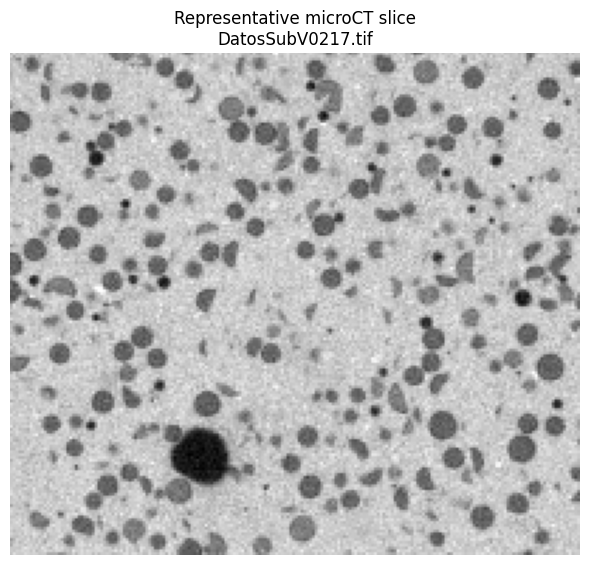

In [7]:
# ============================================================
# Display representative slice
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(sample_slice, cmap="gray")
ax.set_title(f"Representative microCT slice\n{sample_path.name}")
ax.axis("off")

plt.tight_layout()
plt.show()

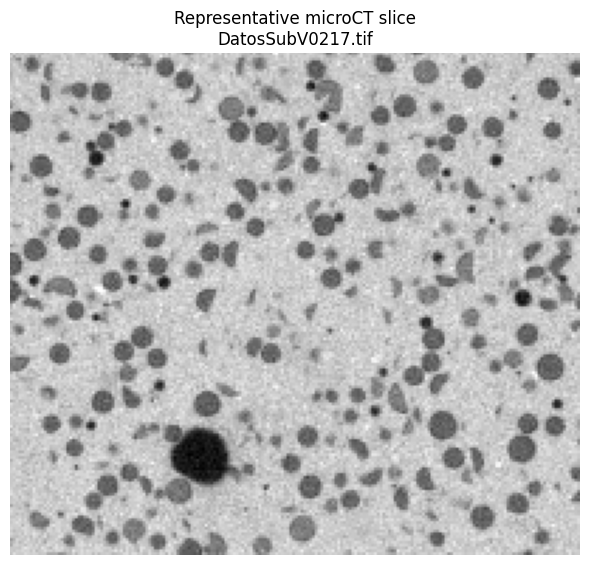

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\representative_slice.png


In [8]:
# ============================================================
# Save representative slice figure
# ============================================================

out_path = FIGURES_DIR / "representative_slice.png"

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(sample_slice, cmap="gray")
ax.set_title(f"Representative microCT slice\n{sample_path.name}")
ax.axis("off")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [9]:
# ============================================================
# Load full microCT stack as a 3D NumPy array
# ============================================================

volume_slices = []

for file in tif_files:
    img = io.imread(file)
    volume_slices.append(img)

volume = np.stack(volume_slices, axis=0)

print("Volume loaded successfully.")
print("Volume shape (Z, Y, X):", volume.shape)
print("Data type:", volume.dtype)
print("Min intensity:", volume.min())
print("Max intensity:", volume.max())
print("Mean intensity:", volume.mean())

Volume loaded successfully.
Volume shape (Z, Y, X): (435, 178, 202)
Data type: uint8
Min intensity: 7
Max intensity: 255
Mean intensity: 185.01312331930598


In [10]:
# ============================================================
# Check expected volume dimensions
# ============================================================

z_size, y_size, x_size = volume.shape

print(f"Z slices: {z_size}")
print(f"Y pixels: {y_size}")
print(f"X pixels: {x_size}")

expected_y = 178
expected_x = 202

if y_size == expected_y and x_size == expected_x:
    print("Slice dimensions match the expected cropped subvolume size.")
else:
    print("Warning: slice dimensions are different from the expected size.")

Z slices: 435
Y pixels: 178
X pixels: 202
Slice dimensions match the expected cropped subvolume size.


In [11]:
# ============================================================
# Physical metadata
# ============================================================

VOXEL_SIZE_UM = 20.0*4

voxel_size_mm = VOXEL_SIZE_UM / 1000.0
voxel_volume_mm3 = voxel_size_mm ** 3

physical_size_z_mm = z_size * voxel_size_mm
physical_size_y_mm = y_size * voxel_size_mm
physical_size_x_mm = x_size * voxel_size_mm

print("Voxel size:")
print(f"  {VOXEL_SIZE_UM:.2f} µm")
print(f"  {voxel_size_mm:.4f} mm")

print("\nVoxel volume:")
print(f"  {voxel_volume_mm3:.8f} mm³")

print("\nPhysical subvolume size:")
print(f"  Z: {physical_size_z_mm:.2f} mm")
print(f"  Y: {physical_size_y_mm:.2f} mm")
print(f"  X: {physical_size_x_mm:.2f} mm")

print("\nTotal analyzed volume:")
total_volume_mm3 = volume.size * voxel_volume_mm3
print(f"  {total_volume_mm3:.4f} mm³")

Voxel size:
  80.00 µm
  0.0800 mm

Voxel volume:
  0.00051200 mm³

Physical subvolume size:
  Z: 34.80 mm
  Y: 14.24 mm
  X: 16.16 mm

Total analyzed volume:
  8008.1203 mm³


In [14]:
# ============================================================
# Global intensity statistics
# ============================================================

intensity_stats = {
    "min": np.min(volume),
    "max": np.max(volume),
    "mean": np.mean(volume),
    "median": np.median(volume),
    "std": np.std(volume),
    "p01": np.percentile(volume, 1),
    "p05": np.percentile(volume, 5),
    "p25": np.percentile(volume, 25),
    "p75": np.percentile(volume, 75),
    "p95": np.percentile(volume, 95),
    "p99": np.percentile(volume, 99),
}

df_intensity_stats = pd.DataFrame([intensity_stats])

df_intensity_stats

,min,max,mean,median,std,p01,p05,p25,p75,p95,p99
0,7,255,185.013123,198.0,36.038782,79.0,108.0,177.0,208.0,221.0,230.0


In [15]:
# ============================================================
# Save global intensity statistics
# ============================================================

out_csv = RESULTS_DIR / "global_intensity_statistics.csv"

df_intensity_stats.to_csv(out_csv, index=False)

print(f"Global intensity statistics saved to: {out_csv}")

Global intensity statistics saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\global_intensity_statistics.csv


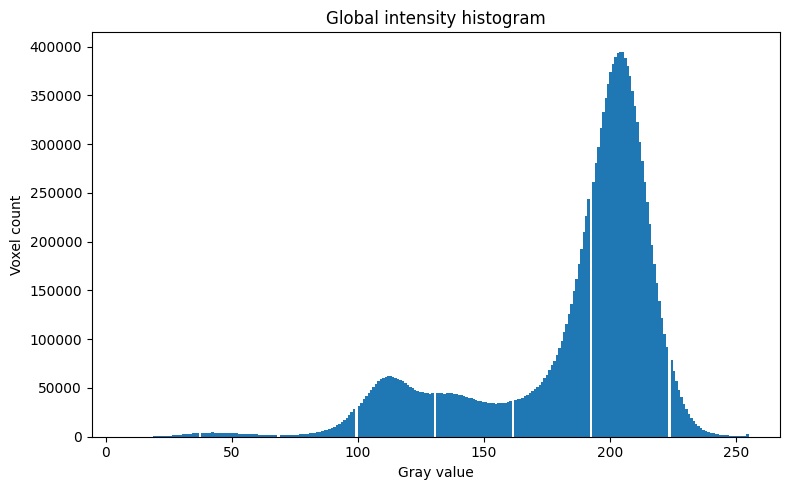

In [16]:
# ============================================================
# Global intensity histogram
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(volume.ravel(), bins=256)
ax.set_title("Global intensity histogram")
ax.set_xlabel("Gray value")
ax.set_ylabel("Voxel count")

plt.tight_layout()
plt.show()

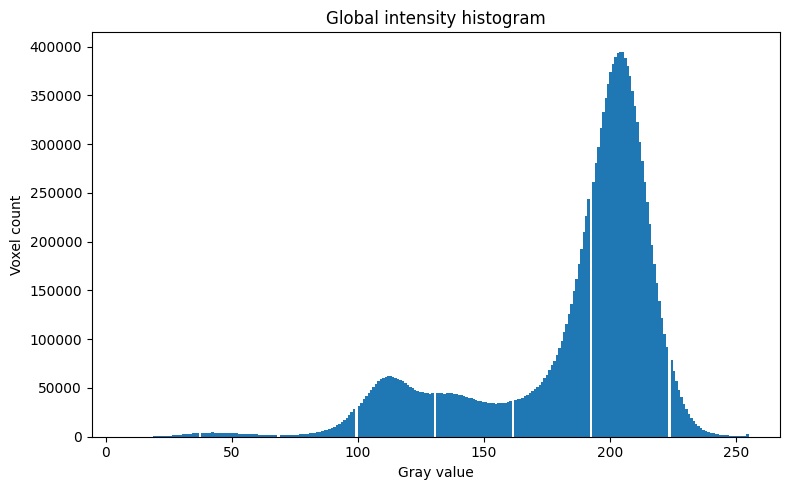

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\global_intensity_histogram.png


In [17]:
# ============================================================
# Save global intensity histogram
# ============================================================

out_path = FIGURES_DIR / "global_intensity_histogram.png"

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(volume.ravel(), bins=256)
ax.set_title("Global intensity histogram")
ax.set_xlabel("Gray value")
ax.set_ylabel("Voxel count")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

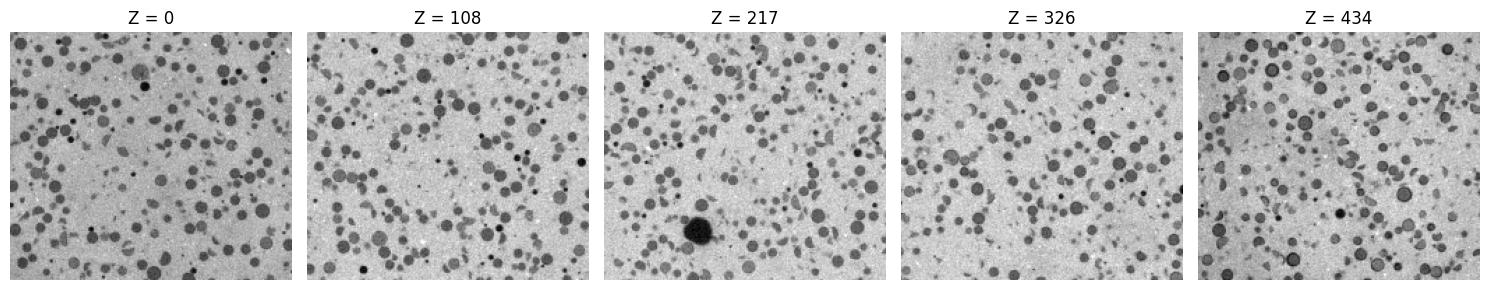

In [18]:
# ============================================================
# Display representative slices along Z
# ============================================================

slice_indices = [
    0,
    z_size // 4,
    z_size // 2,
    3 * z_size // 4,
    z_size - 1
]

fig, axes = plt.subplots(1, len(slice_indices), figsize=(15, 4))

for ax, idx in zip(axes, slice_indices):
    ax.imshow(volume[idx], cmap="gray")
    ax.set_title(f"Z = {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\representative_z_slices.png


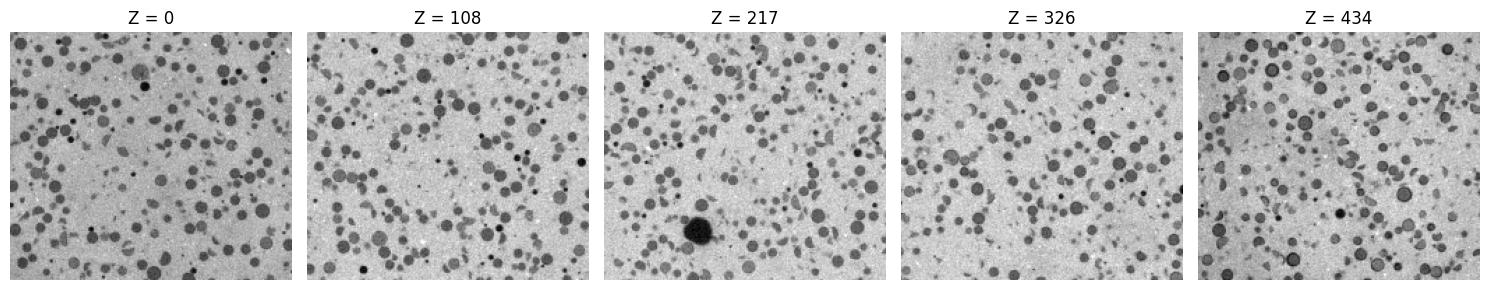

In [19]:
# ============================================================
# Save representative Z slices
# ============================================================

out_path = FIGURES_DIR / "representative_z_slices.png"

fig, axes = plt.subplots(1, len(slice_indices), figsize=(15, 4))

for ax, idx in zip(axes, slice_indices):
    ax.imshow(volume[idx], cmap="gray")
    ax.set_title(f"Z = {idx}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
#plt.show()

print(f"Figure saved to: {out_path}")

In [20]:
# ============================================================
# Detailed intensity percentiles
# ============================================================

percentiles = [0, 1, 2, 5, 10, 25, 50, 75, 90, 95, 98, 99, 100]

intensity_percentiles = {
    f"p{p:02d}" if p < 100 else "p100": np.percentile(volume, p)
    for p in percentiles
}

df_percentiles = pd.DataFrame(
    list(intensity_percentiles.items()),
    columns=["percentile", "gray_value"]
)

df_percentiles

,percentile,gray_value
0,p00,7.0
1,p01,79.0
2,p02,97.0
3,p05,108.0
4,p10,122.0
5,p25,177.0
6,p50,198.0
7,p75,208.0
8,p90,216.0
9,p95,221.0


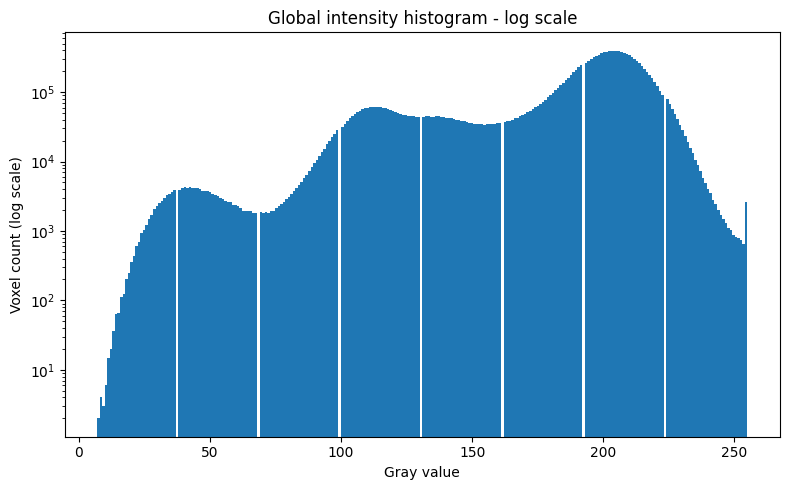

In [21]:
# ============================================================
# Global intensity histogram with logarithmic y-axis
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(volume.ravel(), bins=256)
ax.set_yscale("log")

ax.set_title("Global intensity histogram - log scale")
ax.set_xlabel("Gray value")
ax.set_ylabel("Voxel count (log scale)")

plt.tight_layout()
plt.show()

XY view shape: (178, 202)
XZ view shape: (435, 202)
YZ view shape: (435, 178)


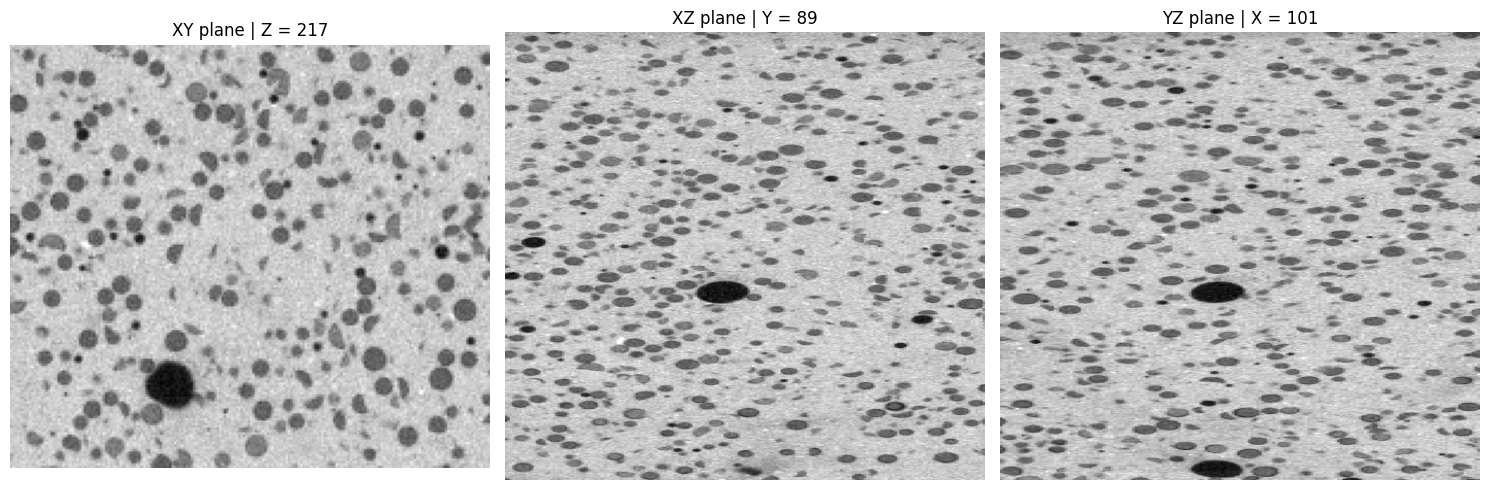

In [22]:
# ============================================================
# Orthogonal views: XY, XZ, YZ
# ============================================================

z_mid = z_size // 2
y_mid = y_size // 2
x_mid = x_size // 2

xy_view = volume[z_mid, :, :]
xz_view = volume[:, y_mid, :]
yz_view = volume[:, :, x_mid]

print("XY view shape:", xy_view.shape)
print("XZ view shape:", xz_view.shape)
print("YZ view shape:", yz_view.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(xy_view, cmap="gray")
axes[0].set_title(f"XY plane | Z = {z_mid}")
axes[0].axis("off")

axes[1].imshow(xz_view, cmap="gray", aspect="auto")
axes[1].set_title(f"XZ plane | Y = {y_mid}")
axes[1].axis("off")

axes[2].imshow(yz_view, cmap="gray", aspect="auto")
axes[2].set_title(f"YZ plane | X = {x_mid}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

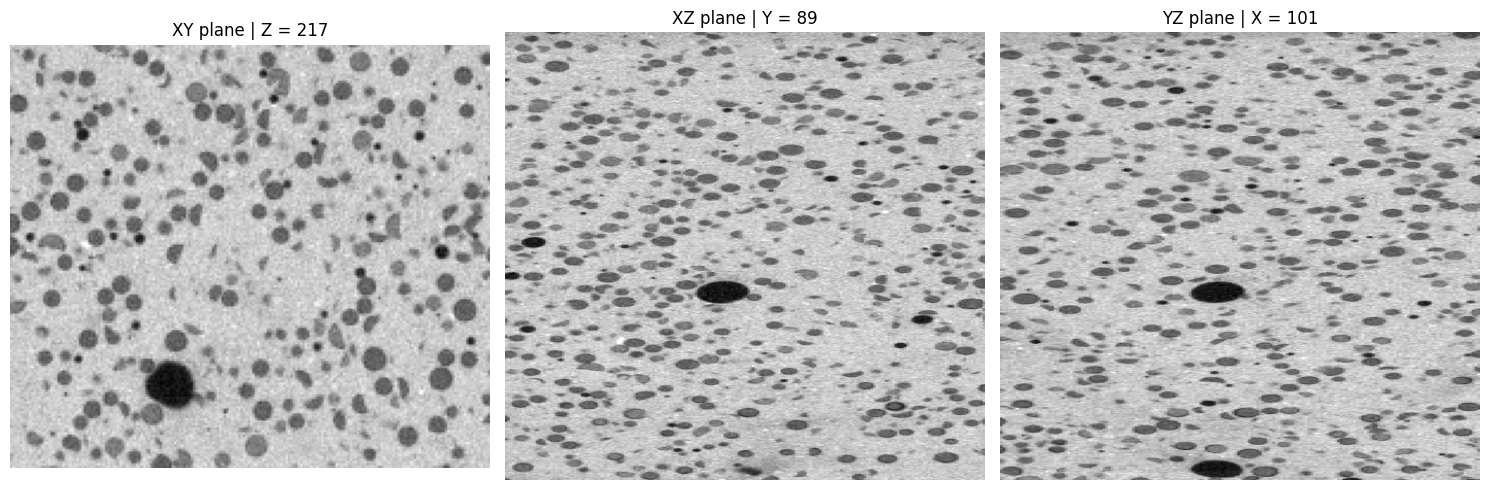

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\orthogonal_views_xy_xz_yz.png


In [23]:
# ============================================================
# Save orthogonal views
# ============================================================

out_path = FIGURES_DIR / "orthogonal_views_xy_xz_yz.png"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(xy_view, cmap="gray")
axes[0].set_title(f"XY plane | Z = {z_mid}")
axes[0].axis("off")

axes[1].imshow(xz_view, cmap="gray", aspect="auto")
axes[1].set_title(f"XZ plane | Y = {y_mid}")
axes[1].axis("off")

axes[2].imshow(yz_view, cmap="gray", aspect="auto")
axes[2].set_title(f"YZ plane | X = {x_mid}")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

Robust contrast limits:
  p01 = 79.00
  p99 = 230.00


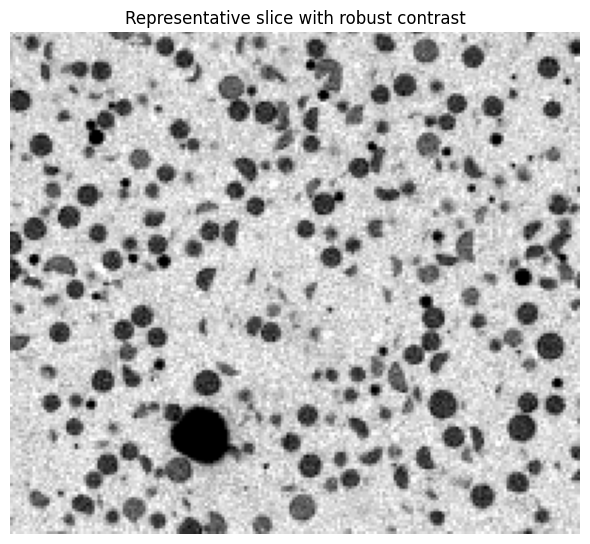

In [24]:
# ============================================================
# Robust contrast visualization
# ============================================================

p_low, p_high = np.percentile(volume, [1, 99])

print(f"Robust contrast limits:")
print(f"  p01 = {p_low:.2f}")
print(f"  p99 = {p_high:.2f}")

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(sample_slice, cmap="gray", vmin=p_low, vmax=p_high)
ax.set_title("Representative slice with robust contrast")
ax.axis("off")

plt.tight_layout()
plt.show()

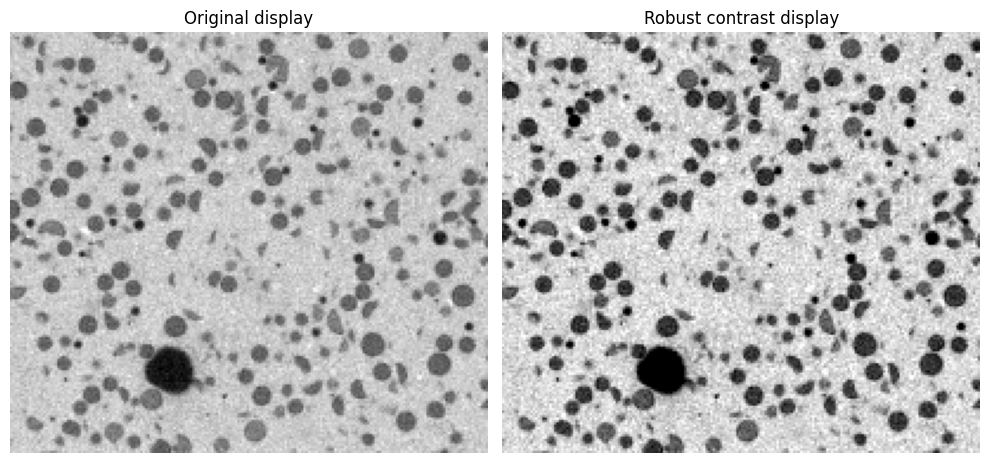

In [25]:
# ============================================================
# Original vs robust contrast comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sample_slice, cmap="gray")
axes[0].set_title("Original display")
axes[0].axis("off")

axes[1].imshow(sample_slice, cmap="gray", vmin=p_low, vmax=p_high)
axes[1].set_title("Robust contrast display")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# Initial intensity thresholds for exploratory segmentation
# ============================================================

# Based on the global percentiles and visual inspection:
# p05 ~ 108
# p25 ~ 177
# p50 ~ 198

PORE_THRESHOLD = 105
INTERMEDIATE_THRESHOLD = 175

print("Initial segmentation thresholds:")
print(f"  Pores / very dark regions: intensity < {PORE_THRESHOLD}")
print(f"  Intermediate dark regions: {PORE_THRESHOLD} <= intensity < {INTERMEDIATE_THRESHOLD}")
print(f"  Bright matrix: intensity >= {INTERMEDIATE_THRESHOLD}")

Initial segmentation thresholds:
  Pores / very dark regions: intensity < 105
  Intermediate dark regions: 105 <= intensity < 175
  Bright matrix: intensity >= 175


In [27]:
# ============================================================
# Create initial 3D masks
# ============================================================

pores_mask = volume < PORE_THRESHOLD

intermediate_mask = (volume >= PORE_THRESHOLD) & (volume < INTERMEDIATE_THRESHOLD)

matrix_mask = volume >= INTERMEDIATE_THRESHOLD

print("Mask shapes:")
print("  pores_mask:", pores_mask.shape)
print("  intermediate_mask:", intermediate_mask.shape)
print("  matrix_mask:", matrix_mask.shape)

print("\nVoxel counts:")
print("  pores:", pores_mask.sum())
print("  intermediate:", intermediate_mask.sum())
print("  matrix:", matrix_mask.sum())

print("\nVolume fractions:")
print(f"  pores: {pores_mask.mean():.4f}")
print(f"  intermediate: {intermediate_mask.mean():.4f}")
print(f"  matrix: {matrix_mask.mean():.4f}")

Mask shapes:
  pores_mask: (435, 178, 202)
  intermediate_mask: (435, 178, 202)
  matrix_mask: (435, 178, 202)

Voxel counts:
  pores: 573879
  intermediate: 3201763
  matrix: 11865218

Volume fractions:
  pores: 0.0367
  intermediate: 0.2047
  matrix: 0.7586


In [28]:
# ============================================================
# Create labeled phase volume
# ============================================================

# Labels:
# 0 = pores / very dark regions
# 1 = intermediate dark regions
# 2 = bright matrix

phase_labels = np.zeros_like(volume, dtype=np.uint8)

phase_labels[intermediate_mask] = 1
phase_labels[matrix_mask] = 2

print("Phase label volume created.")
print("Unique labels:", np.unique(phase_labels))

Phase label volume created.
Unique labels: [0 1 2]


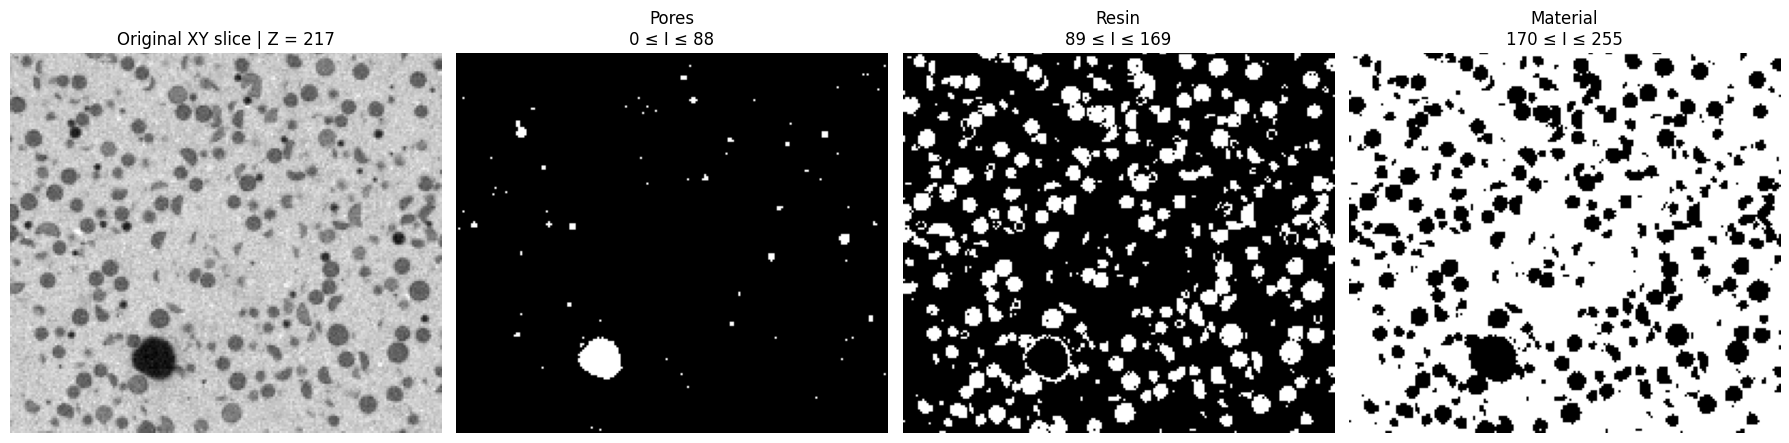

In [29]:
# ============================================================
# Cell 30 - Visualize the 3 selected phases on XY slice
# 4 panels: original + pores + resin + material
# ============================================================

z_vis = z_mid
slice_xy = volume[z_vis]

# Selected thresholds
PORE_MAX = 88
RESIN_MIN = 89
RESIN_MAX = 169
MATERIAL_MIN = 170

# Phase masks
pores_mask_xy = slice_xy <= PORE_MAX
resin_mask_xy = (slice_xy >= RESIN_MIN) & (slice_xy <= RESIN_MAX)
material_mask_xy = slice_xy >= MATERIAL_MIN

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Original slice
axes[0].imshow(slice_xy, cmap="gray")
axes[0].set_title(f"Original XY slice | Z = {z_vis}")
axes[0].axis("off")

# Pores
axes[1].imshow(pores_mask_xy, cmap="gray")
axes[1].set_title("Pores\n0 ≤ I ≤ 88")
axes[1].axis("off")

# Resin
axes[2].imshow(resin_mask_xy, cmap="gray")
axes[2].set_title("Resin\n89 ≤ I ≤ 169")
axes[2].axis("off")

# Material
axes[3].imshow(material_mask_xy, cmap="gray")
axes[3].set_title("Material\n170 ≤ I ≤ 255")
axes[3].axis("off")

plt.tight_layout()
plt.show()

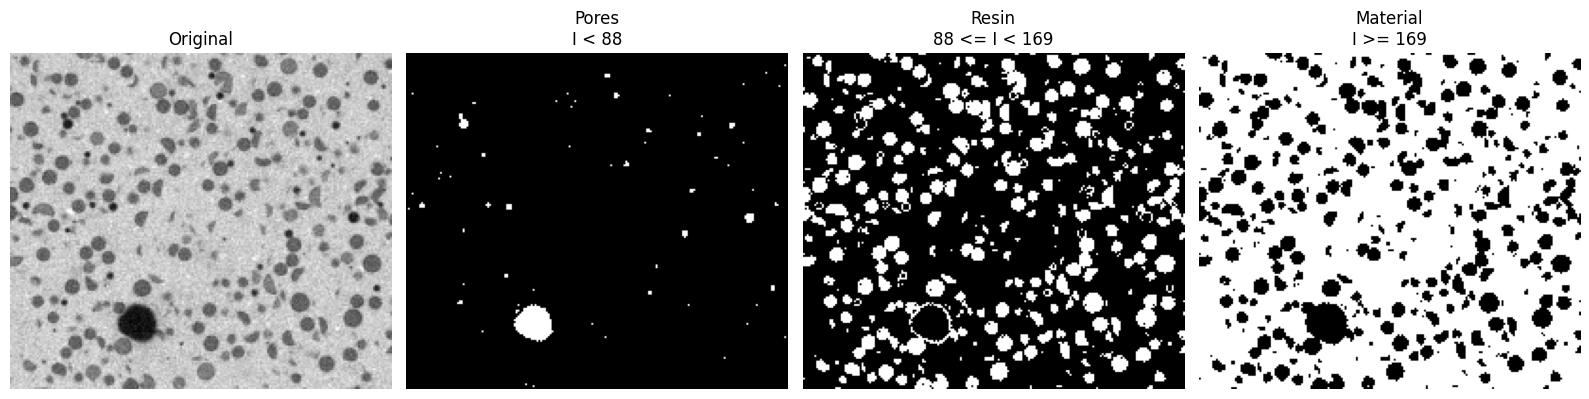

In [30]:
# ============================================================
# Cell 31 - Show individual masks for one threshold set
# ============================================================

# Change these values after visual inspection
PORE_THRESHOLD = 88
RESIN_THRESHOLD = 169

labels_preview = np.digitize(slice_xy, bins=[PORE_THRESHOLD, RESIN_THRESHOLD]).astype(np.uint8)

pores_preview = labels_preview == 0
resin_preview = labels_preview == 1
material_preview = labels_preview == 2

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(slice_xy, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(pores_preview, cmap="gray")
axes[1].set_title(f"Pores\nI < {PORE_THRESHOLD}")
axes[1].axis("off")

axes[2].imshow(resin_preview, cmap="gray")
axes[2].set_title(f"Resin\n{PORE_THRESHOLD} <= I < {RESIN_THRESHOLD}")
axes[2].axis("off")

axes[3].imshow(material_preview, cmap="gray")
axes[3].set_title(f"Material\nI >= {RESIN_THRESHOLD}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

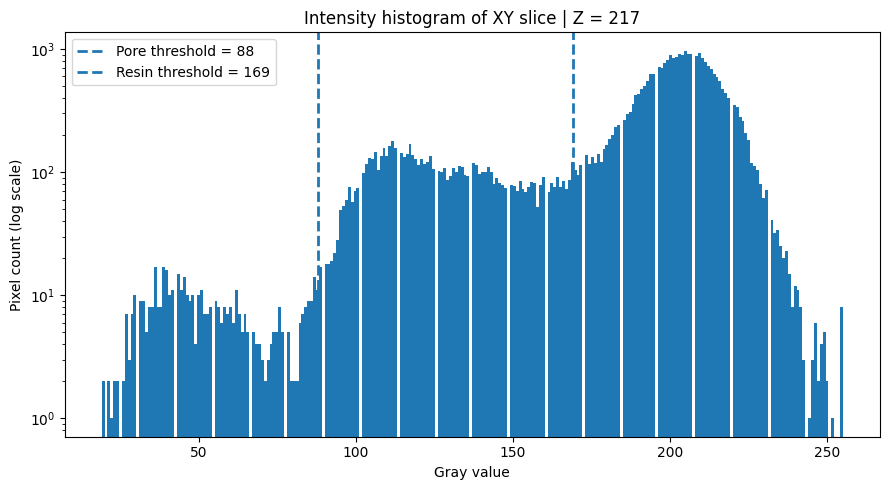

In [31]:
# ============================================================
# Cell 32 - Histogram of XY slice with selected thresholds
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(slice_xy.ravel(), bins=256)
ax.set_yscale("log")

ax.axvline(PORE_THRESHOLD, linestyle="--", linewidth=2, label=f"Pore threshold = {PORE_THRESHOLD}")
ax.axvline(RESIN_THRESHOLD, linestyle="--", linewidth=2, label=f"Resin threshold = {RESIN_THRESHOLD}")

ax.set_title(f"Intensity histogram of XY slice | Z = {z_vis}")
ax.set_xlabel("Gray value")
ax.set_ylabel("Pixel count (log scale)")
ax.legend()

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# Cell 33 - Create 3-phase segmentation for the full volume
# ============================================================

phase_labels = np.digitize(volume, bins=[PORE_THRESHOLD, RESIN_THRESHOLD]).astype(np.uint8)

print("3-phase volume segmentation created.")
print("Unique labels:", np.unique(phase_labels))
print("0 = pores, 1 = resin, 2 = material")

from matplotlib.colors import ListedColormap

# 0 = pores, 1 = resin, 2 = material
phase_cmap = ListedColormap([
    "black",       # pores
    "orange",      # resin
    "lightgray"    # material
])

phase_names = {
    0: "pores",
    1: "resin",
    2: "material"
}

print("Custom colormap for 3 phases created.")
print(phase_names)

3-phase volume segmentation created.
Unique labels: [0 1 2]
0 = pores, 1 = resin, 2 = material
Custom colormap for 3 phases created.
{0: 'pores', 1: 'resin', 2: 'material'}


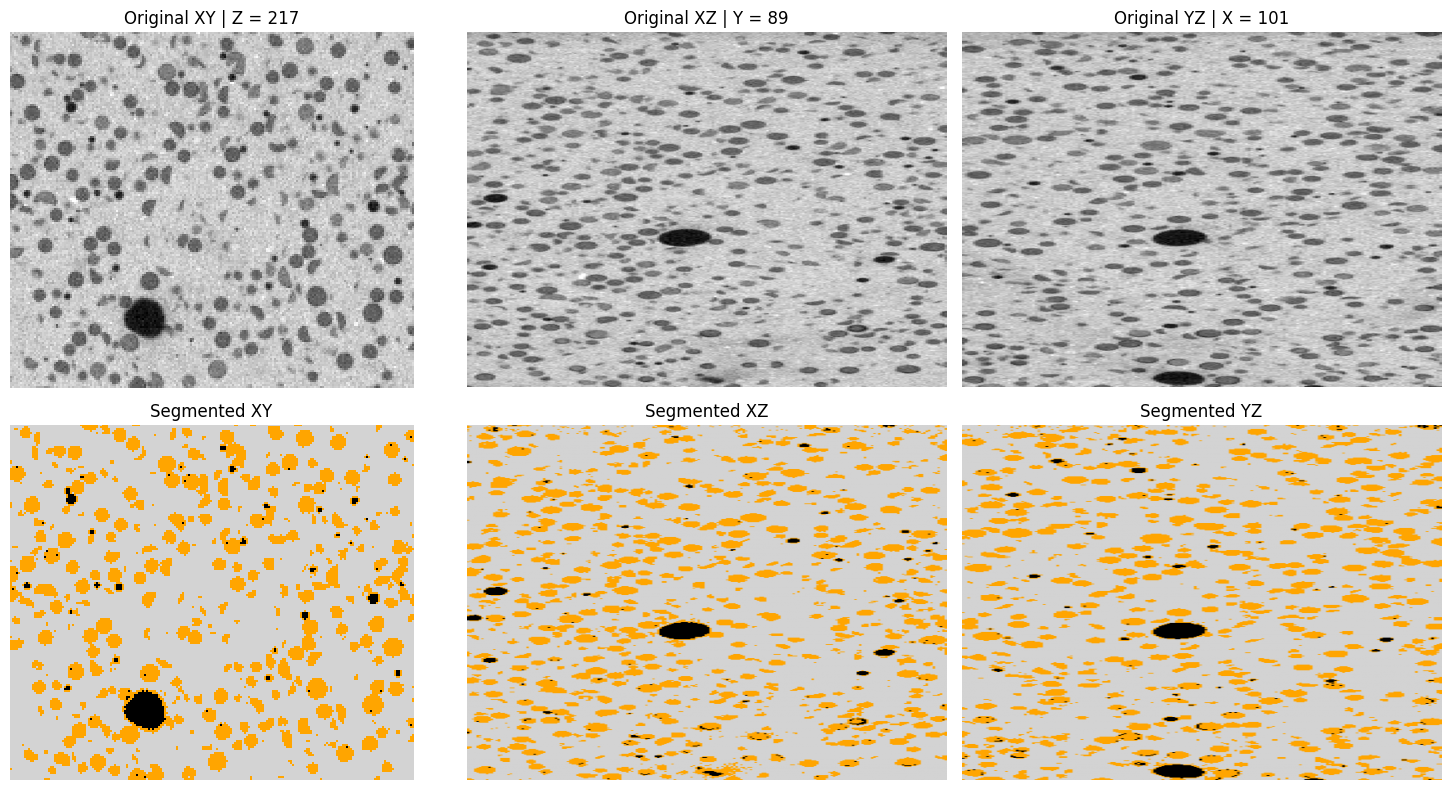

In [33]:
# ============================================================
# Cell 34 - Visualize 3-phase segmentation in orthogonal planes
# ============================================================

xy_phase = phase_labels[z_mid, :, :]
xz_phase = phase_labels[:, y_mid, :]
yz_phase = phase_labels[:, :, x_mid]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Original
axes[0, 0].imshow(volume[z_mid], cmap="gray")
axes[0, 0].set_title(f"Original XY | Z = {z_mid}")
axes[0, 0].axis("off")

axes[0, 1].imshow(volume[:, y_mid, :], cmap="gray", aspect="auto")
axes[0, 1].set_title(f"Original XZ | Y = {y_mid}")
axes[0, 1].axis("off")

axes[0, 2].imshow(volume[:, :, x_mid], cmap="gray", aspect="auto")
axes[0, 2].set_title(f"Original YZ | X = {x_mid}")
axes[0, 2].axis("off")

# Segmented
axes[1, 0].imshow(xy_phase, cmap=phase_cmap, vmin=0, vmax=2)
axes[1, 0].set_title("Segmented XY")
axes[1, 0].axis("off")

axes[1, 1].imshow(xz_phase, cmap=phase_cmap, vmin=0, vmax=2, aspect="auto")
axes[1, 1].set_title("Segmented XZ")
axes[1, 1].axis("off")

axes[1, 2].imshow(yz_phase, cmap=phase_cmap, vmin=0, vmax=2, aspect="auto")
axes[1, 2].set_title("Segmented YZ")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# Cell 35 - Global summary of the 3 phases
# ============================================================

pores_mask = phase_labels == 0
resin_mask = phase_labels == 1
material_mask = phase_labels == 2

phase_summary = pd.DataFrame({
    "phase": ["pores", "resin", "material"],
    "label": [0, 1, 2],
    "voxel_count": [
        pores_mask.sum(),
        resin_mask.sum(),
        material_mask.sum()
    ]
})

phase_summary["volume_fraction"] = phase_summary["voxel_count"] / volume.size
phase_summary["volume_mm3"] = phase_summary["voxel_count"] * voxel_volume_mm3

phase_summary

,phase,label,voxel_count,volume_fraction,volume_mm3
0,pores,0,192848,0.012330,98.738176
1,resin,1,3265945,0.208809,1672.163840
2,material,2,12182067,0.778862,6237.218304


In [35]:
# ============================================================
# Cell 36 - Slice-by-slice phase fractions along Z
# ============================================================

# Masks from the 3-phase segmentation
pores_mask = phase_labels == 0
resin_mask = phase_labels == 1
material_mask = phase_labels == 2

# Slice indices
z_indices = np.arange(z_size)

# Phase fractions per slice
pores_fraction_z = pores_mask.mean(axis=(1, 2))
resin_fraction_z = resin_mask.mean(axis=(1, 2))
material_fraction_z = material_mask.mean(axis=(1, 2))

# Physical Z position
z_position_mm = z_indices * voxel_size_mm

# Build dataframe
df_slice_phase_fractions = pd.DataFrame({
    "z_index": z_indices,
    "z_position_mm": z_position_mm,
    "pores_fraction": pores_fraction_z,
    "resin_fraction": resin_fraction_z,
    "material_fraction": material_fraction_z,
})

# Check that fractions add up to 1
df_slice_phase_fractions["total_fraction"] = (
    df_slice_phase_fractions["pores_fraction"] +
    df_slice_phase_fractions["resin_fraction"] +
    df_slice_phase_fractions["material_fraction"]
)

df_slice_phase_fractions.head()

,z_index,z_position_mm,pores_fraction,resin_fraction,material_fraction,total_fraction
0,0,0.00,0.056875,0.321059,0.622066,1.0
1,1,0.08,0.049366,0.312271,0.638364,1.0
2,2,0.16,0.040800,0.301925,0.657276,1.0
3,3,0.24,0.033513,0.292524,0.673963,1.0
4,4,0.32,0.028952,0.273418,0.697630,1.0


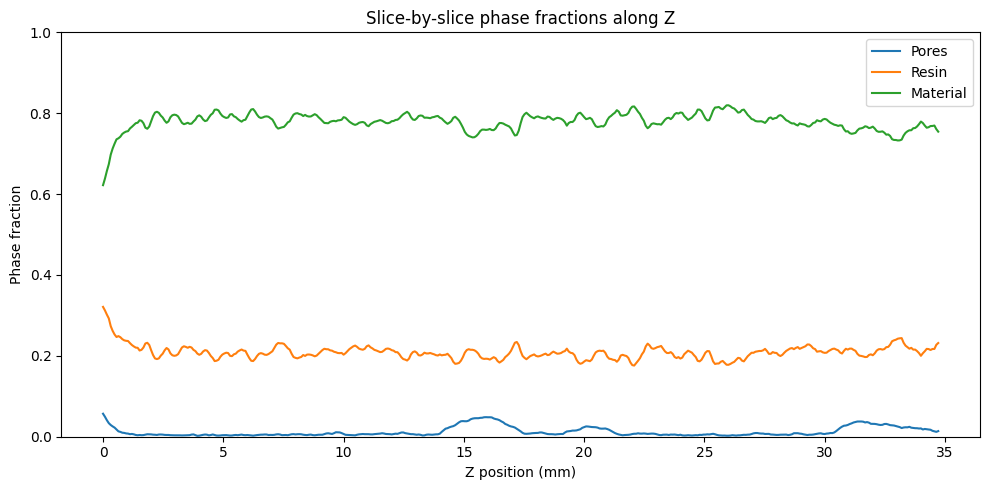

In [36]:
# ============================================================
# Cell 37 - Plot slice-by-slice phase fractions along Z
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["pores_fraction"],
    label="Pores"
)

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["resin_fraction"],
    label="Resin"
)

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["material_fraction"],
    label="Material"
)

ax.set_title("Slice-by-slice phase fractions along Z")
ax.set_xlabel("Z position (mm)")
ax.set_ylabel("Phase fraction")
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

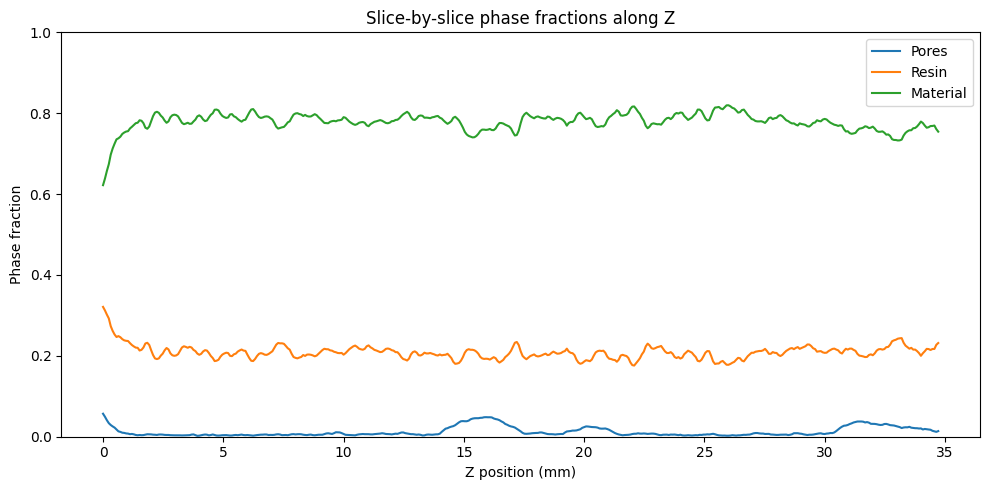

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\phase_fractions_vs_z.png


In [37]:
# ============================================================
# Cell 38 - Save slice-by-slice phase fractions plot
# ============================================================

out_path = FIGURES_DIR / "phase_fractions_vs_z.png"

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["pores_fraction"],
    label="Pores"
)

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["resin_fraction"],
    label="Resin"
)

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["material_fraction"],
    label="Material"
)

ax.set_title("Slice-by-slice phase fractions along Z")
ax.set_xlabel("Z position (mm)")
ax.set_ylabel("Phase fraction")
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [38]:
# ============================================================
# Cell 39 - Save slice-by-slice phase fractions table
# ============================================================

out_csv = RESULTS_DIR / "slice_by_slice_phase_fractions.csv"

df_slice_phase_fractions.to_csv(out_csv, index=False)

print(f"Slice-by-slice phase fractions saved to: {out_csv}")

Slice-by-slice phase fractions saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\slice_by_slice_phase_fractions.csv


In [39]:
# ============================================================
# Cell 40 - Descriptive statistics of phase fractions along Z
# ============================================================

fraction_columns = [
    "pores_fraction",
    "resin_fraction",
    "material_fraction"
]

df_phase_fraction_stats = df_slice_phase_fractions[fraction_columns].describe().T

df_phase_fraction_stats["coefficient_of_variation"] = (
    df_phase_fraction_stats["std"] / df_phase_fraction_stats["mean"]
)

df_phase_fraction_stats

,count,mean,std,min,25%,50%,75%,max,coefficient_of_variation
pores_fraction,435.0,0.012330,0.011771,0.002225,0.004728,0.006675,0.017521,0.056875,0.954719
resin_fraction,435.0,0.208809,0.016981,0.175965,0.199675,0.207615,0.216556,0.321059,0.081323
material_fraction,435.0,0.778862,0.022066,0.622066,0.769524,0.781761,0.792051,0.819613,0.028331


In [40]:
"""
The resin and material fractions remain relatively stable along the Z direction, suggesting that the selected subvolume is 
representative in terms of bulk phase distribution. The pore fraction shows higher relative variability, mainly because pores 
occupy a much smaller volume fraction and are more sensitive to local spatial fluctuations.
"""

'\nThe resin and material fractions remain relatively stable along the Z direction, suggesting that the selected subvolume is \nrepresentative in terms of bulk phase distribution. The pore fraction shows higher relative variability, mainly because pores \noccupy a much smaller volume fraction and are more sensitive to local spatial fluctuations.\n'

In [41]:
# ============================================================
# Cell 41 - Save descriptive statistics of phase fractions
# ============================================================

out_csv = RESULTS_DIR / "phase_fraction_descriptive_statistics.csv"

df_phase_fraction_stats.to_csv(out_csv)

print(f"Phase fraction descriptive statistics saved to: {out_csv}")

Phase fraction descriptive statistics saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\phase_fraction_descriptive_statistics.csv


In [42]:
# ============================================================
# Cell 42 - Helper function for 2D connected-component analysis
# Updated circularity calculation using Crofton perimeter
# ============================================================

def analyze_2d_components(mask_2d, intensity_image_2d, z_index, phase_name, min_area_pixels=5):
    """
    Analyze connected components in a 2D binary mask.

    Parameters
    ----------
    mask_2d : 2D boolean array
        Binary mask for a given phase in one slice.
    intensity_image_2d : 2D array
        Original grayscale image corresponding to the same slice.
    z_index : int
        Slice index along the Z axis.
    phase_name : str
        Name of the analyzed phase.
    min_area_pixels : int
        Minimum object area in pixels to keep.

    Returns
    -------
    list of dict
        One dictionary per connected component.
    """

    labeled_mask = measure.label(mask_2d, connectivity=2)

    props = measure.regionprops(
        labeled_mask,
        intensity_image=intensity_image_2d
    )

    rows = []

    for prop in props:
        if prop.area < min_area_pixels:
            continue

        area_pixels = prop.area
        area_mm2 = area_pixels * (voxel_size_mm ** 2)

        # Crofton perimeter is more robust for pixelated binary objects
        perimeter_crofton = measure.perimeter_crofton(prop.image, directions=4)

        if perimeter_crofton > 0:
            circularity = 4 * np.pi * area_pixels / (perimeter_crofton ** 2)
        else:
            circularity = np.nan

        # Physically interpretable circularity should not exceed 1
        circularity_clipped = min(circularity, 1.0) if not np.isnan(circularity) else np.nan

        major_axis = prop.axis_major_length
        minor_axis = prop.axis_minor_length

        if minor_axis > 0:
            aspect_ratio = major_axis / minor_axis
        else:
            aspect_ratio = np.nan

        centroid_y, centroid_x = prop.centroid

        equivalent_diameter_pixels = prop.equivalent_diameter_area

        rows.append({
            "phase": phase_name,
            "z_index": z_index,
            "z_position_mm": z_index * voxel_size_mm,
            "label_2d": prop.label,

            "area_pixels": area_pixels,
            "area_mm2": area_mm2,

            "equivalent_diameter_pixels": equivalent_diameter_pixels,
            "equivalent_diameter_um": equivalent_diameter_pixels * VOXEL_SIZE_UM,

            "perimeter_crofton_pixels": perimeter_crofton,
            "circularity": circularity,
            "circularity_clipped": circularity_clipped,

            "eccentricity": prop.eccentricity,
            "major_axis_length_pixels": major_axis,
            "minor_axis_length_pixels": minor_axis,
            "aspect_ratio": aspect_ratio,
            "solidity": prop.solidity,
            "extent": prop.extent,

            "centroid_y_pixels": centroid_y,
            "centroid_x_pixels": centroid_x,
            "centroid_y_mm": centroid_y * voxel_size_mm,
            "centroid_x_mm": centroid_x * voxel_size_mm,

            "mean_intensity": prop.intensity_mean,
            "min_intensity": prop.intensity_min,
            "max_intensity": prop.intensity_max,
        })

    return rows

In [43]:
# ============================================================
# Cell 43 - Test 2D component analysis on one representative slice
# ============================================================

z_test = z_mid

pores_slice = pores_mask[z_test]
resin_slice = resin_mask[z_test]

rows_pores_test = analyze_2d_components(
    mask_2d=pores_slice,
    intensity_image_2d=volume[z_test],
    z_index=z_test,
    phase_name="pores",
    min_area_pixels=5
)

rows_resin_test = analyze_2d_components(
    mask_2d=resin_slice,
    intensity_image_2d=volume[z_test],
    z_index=z_test,
    phase_name="resin",
    min_area_pixels=5
)

df_components_2d_test = pd.DataFrame(rows_pores_test + rows_resin_test)

print("Number of 2D components in test slice:", len(df_components_2d_test))
df_components_2d_test.head()

Number of 2D components in test slice: 228


,phase,z_index,z_position_mm,label_2d,area_pixels,area_mm2,equivalent_diameter_pixels,equivalent_diameter_um,perimeter_crofton_pixels,circularity,...,aspect_ratio,solidity,extent,centroid_y_pixels,centroid_x_pixels,centroid_y_mm,centroid_x_mm,mean_intensity,min_intensity,max_intensity
0,pores,217,17.36,3,6.0,0.0384,2.763953,221.116256,8.369874,1.076275,...,1.632993,1.00000,1.000000,11.500000,106.000000,0.920000,8.480000,60.500000,39.0,86.0
1,pores,217,17.36,8,7.0,0.0448,2.985411,238.832853,9.155272,1.049459,...,1.080123,1.00000,0.777778,22.000000,110.714286,1.760000,8.857143,57.000000,29.0,70.0
2,pores,217,17.36,14,26.0,0.1664,5.753627,460.290191,22.102782,0.668789,...,1.915440,0.83871,0.650000,36.115385,29.730769,2.889231,2.378462,61.653846,34.0,86.0
3,pores,217,17.36,16,8.0,0.0512,3.191538,255.323059,9.710632,1.066117,...,1.264911,1.00000,0.888889,37.875000,171.875000,3.030000,13.750000,58.875000,48.0,70.0
4,pores,217,17.36,17,5.0,0.0320,2.523133,201.850602,7.814513,1.028907,...,1.732051,1.00000,0.833333,40.600000,127.800000,3.248000,10.224000,66.000000,57.0,84.0


In [44]:
# ============================================================
# Cell 44 - Summary of 2D components in the test slice
# ============================================================

df_components_2d_test.groupby("phase").agg(
    number_of_objects=("label_2d", "count"),
    mean_area_pixels=("area_pixels", "mean"),
    median_area_pixels=("area_pixels", "median"),
    mean_equivalent_diameter_um=("equivalent_diameter_um", "mean"),
    median_equivalent_diameter_um=("equivalent_diameter_um", "median"),
    mean_circularity=("circularity", "mean"),
    mean_aspect_ratio=("aspect_ratio", "mean"),
    mean_intensity=("mean_intensity", "mean")
)

,number_of_objects,mean_area_pixels,median_area_pixels,mean_equivalent_diameter_um,median_equivalent_diameter_um,mean_circularity,mean_aspect_ratio,mean_intensity
phase,,,,,,,,
pores,15,27.533333,7.0,344.216537,238.832853,0.993599,1.358587,61.328747
resin,213,34.816901,26.0,489.145938,460.290191,0.776579,1.608523,132.508384


In [45]:
# ============================================================
# Cell 45 - Run 2D connected-component analysis on all slices
# ============================================================

all_components_2d = []

MIN_AREA_PIXELS_2D = 5

for z in range(z_size):
    # Binary masks for current slice
    pores_slice = pores_mask[z]
    resin_slice = resin_mask[z]
    
    # Original intensity slice
    intensity_slice = volume[z]
    
    # Analyze pores
    rows_pores = analyze_2d_components(
        mask_2d=pores_slice,
        intensity_image_2d=intensity_slice,
        z_index=z,
        phase_name="pores",
        min_area_pixels=MIN_AREA_PIXELS_2D
    )
    
    # Analyze resin
    rows_resin = analyze_2d_components(
        mask_2d=resin_slice,
        intensity_image_2d=intensity_slice,
        z_index=z,
        phase_name="resin",
        min_area_pixels=MIN_AREA_PIXELS_2D
    )
    
    all_components_2d.extend(rows_pores)
    all_components_2d.extend(rows_resin)

df_components_2d = pd.DataFrame(all_components_2d)

print("2D connected-component analysis completed.")
print("Total number of 2D components:", len(df_components_2d))
print("Analyzed slices:", z_size)

df_components_2d.head()

2D connected-component analysis completed.
Total number of 2D components: 91613
Analyzed slices: 435


,phase,z_index,z_position_mm,label_2d,area_pixels,area_mm2,equivalent_diameter_pixels,equivalent_diameter_um,perimeter_crofton_pixels,circularity,...,aspect_ratio,solidity,extent,centroid_y_pixels,centroid_x_pixels,centroid_y_mm,centroid_x_mm,mean_intensity,min_intensity,max_intensity
0,pores,0,0.0,1,7.0,0.0448,2.985411,238.832853,11.051391,0.720235,...,2.096953,0.875000,0.583333,0.571429,119.000000,0.045714,9.520000,82.857143,79.0,87.0
1,pores,0,0.0,2,18.0,0.1152,4.787307,382.984589,24.133654,0.388362,...,1.280274,0.782609,0.600000,1.666667,187.500000,0.133333,15.000000,78.444444,69.0,87.0
2,pores,0,0.0,4,24.0,0.1536,5.527906,442.232511,28.576536,0.369319,...,2.309641,0.615385,0.533333,3.291667,65.625000,0.263333,5.250000,64.166667,27.0,87.0
3,pores,0,0.0,5,52.0,0.3328,8.136858,650.948631,70.600127,0.131100,...,1.666862,0.547368,0.337662,8.288462,149.000000,0.663077,11.920000,80.288462,65.0,87.0
4,pores,0,0.0,7,34.0,0.2176,6.579525,526.361971,43.784956,0.222864,...,1.084207,0.693878,0.531250,8.294118,7.352941,0.663529,0.588235,79.911765,59.0,87.0


In [46]:
# ============================================================
# Cell 46 - Global summary of 2D components by phase
# ============================================================

df_components_2d_summary = df_components_2d.groupby("phase").agg(
    number_of_objects=("label_2d", "count"),
    mean_area_pixels=("area_pixels", "mean"),
    median_area_pixels=("area_pixels", "median"),
    std_area_pixels=("area_pixels", "std"),
    mean_equivalent_diameter_um=("equivalent_diameter_um", "mean"),
    median_equivalent_diameter_um=("equivalent_diameter_um", "median"),
    std_equivalent_diameter_um=("equivalent_diameter_um", "std"),
    mean_circularity=("circularity", "mean"),
    median_circularity=("circularity", "median"),
    mean_eccentricity=("eccentricity", "mean"),
    mean_aspect_ratio=("aspect_ratio", "mean"),
    median_aspect_ratio=("aspect_ratio", "median"),
    mean_solidity=("solidity", "mean"),
    mean_intensity=("mean_intensity", "mean"),
    median_intensity=("mean_intensity", "median")
)

df_components_2d_summary

,number_of_objects,mean_area_pixels,median_area_pixels,std_area_pixels,mean_equivalent_diameter_um,median_equivalent_diameter_um,std_equivalent_diameter_um,mean_circularity,median_circularity,mean_eccentricity,mean_aspect_ratio,median_aspect_ratio,mean_solidity,mean_intensity,median_intensity
phase,,,,,,,,,,,,,,,
pores,5280,29.560417,9.0,116.130957,362.344433,270.811000,331.069805,0.907221,1.017346,0.555469,1.495910,1.224745,0.915935,64.928671,63.375000
resin,86333,36.813872,27.0,35.775384,499.255427,469.058411,225.235480,0.753832,0.812049,0.666057,1.658923,1.464334,0.863796,133.814264,132.846154


In [47]:
# ============================================================
# Cell 47 - Number of 2D objects per slice
# ============================================================

df_objects_per_slice = (
    df_components_2d
    .groupby(["z_index", "z_position_mm", "phase"])
    .size()
    .reset_index(name="number_of_objects")
)

df_objects_per_slice.head()

,z_index,z_position_mm,phase,number_of_objects
0,0,0.00,pores,106
1,0,0.00,resin,178
2,1,0.08,pores,97
3,1,0.08,resin,194
4,2,0.16,pores,79


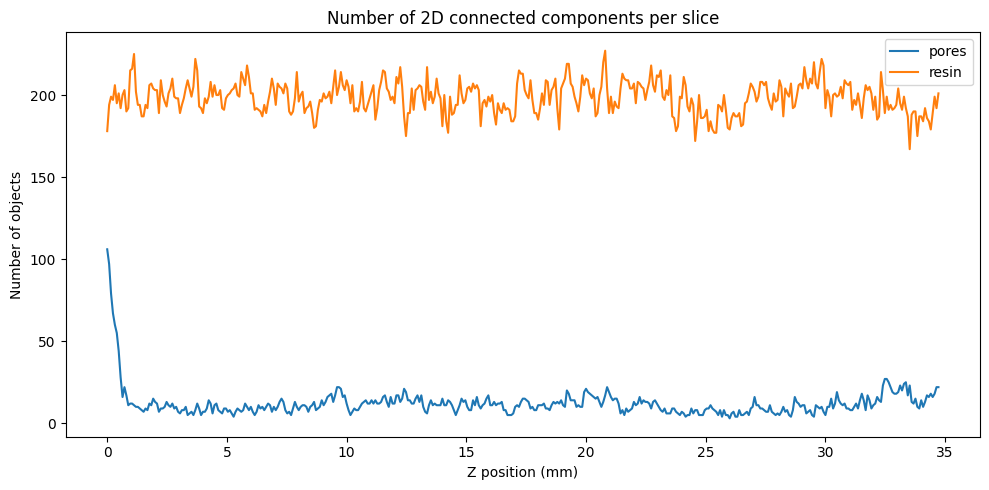

In [48]:
# ============================================================
# Cell 48 - Plot number of 2D objects per slice
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

for phase in df_objects_per_slice["phase"].unique():
    df_phase = df_objects_per_slice[df_objects_per_slice["phase"] == phase]
    
    ax.plot(
        df_phase["z_position_mm"],
        df_phase["number_of_objects"],
        label=phase
    )

ax.set_title("Number of 2D connected components per slice")
ax.set_xlabel("Z position (mm)")
ax.set_ylabel("Number of objects")
ax.legend()

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# Cell 49 - Save 2D connected-component table
# ============================================================

out_csv = RESULTS_DIR / "components_2d_slice_by_slice.csv"

df_components_2d.to_csv(out_csv, index=False)

print(f"2D connected-component table saved to: {out_csv}")

2D connected-component table saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\components_2d_slice_by_slice.csv


In [58]:
# ============================================================
# Cell 50 - Save 2D connected-component summary
# ============================================================

out_csv = RESULTS_DIR / "components_2d_summary_by_phase.csv"

df_components_2d_summary.to_csv(out_csv)

print(f"2D connected-component summary saved to: {out_csv}")

2D connected-component summary saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\components_2d_summary_by_phase.csv


In [59]:
# ============================================================
# Cell 51 - Save number of 2D objects per slice
# ============================================================

out_csv = RESULTS_DIR / "objects_2d_per_slice.csv"

df_objects_per_slice.to_csv(out_csv, index=False)

print(f"2D objects per slice table saved to: {out_csv}")

2D objects per slice table saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\objects_2d_per_slice.csv


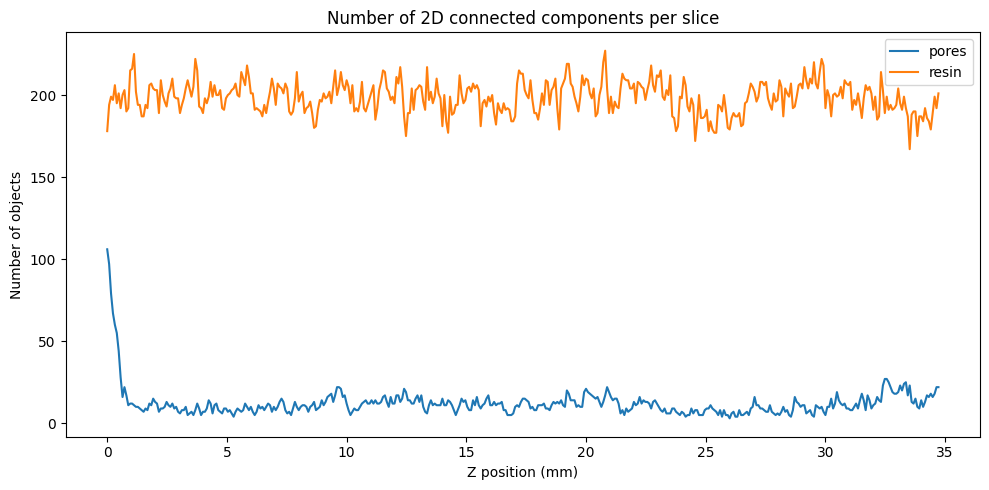

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\objects_2d_per_slice.png


In [50]:
# ============================================================
# Cell 52 - Save number of 2D objects per slice plot
# ============================================================

out_path = FIGURES_DIR / "objects_2d_per_slice.png"

fig, ax = plt.subplots(figsize=(10, 5))

for phase in df_objects_per_slice["phase"].unique():
    df_phase = df_objects_per_slice[df_objects_per_slice["phase"] == phase]
    
    ax.plot(
        df_phase["z_position_mm"],
        df_phase["number_of_objects"],
        label=phase
    )

ax.set_title("Number of 2D connected components per slice")
ax.set_xlabel("Z position (mm)")
ax.set_ylabel("Number of objects")
ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

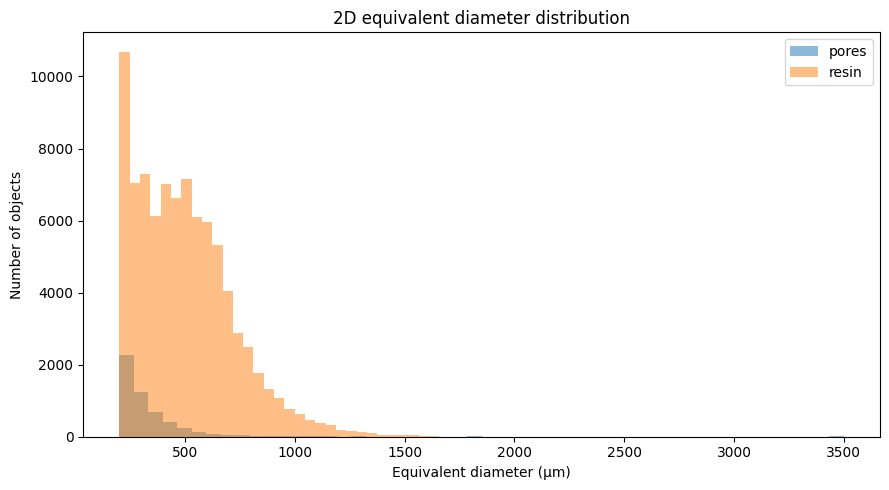

In [51]:
# ============================================================
# Cell 53 - Equivalent diameter distribution of 2D components
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

for phase in df_components_2d["phase"].unique():
    df_phase = df_components_2d[df_components_2d["phase"] == phase]
    
    ax.hist(
        df_phase["equivalent_diameter_um"],
        bins=50,
        alpha=0.5,
        label=phase
    )

ax.set_title("2D equivalent diameter distribution")
ax.set_xlabel("Equivalent diameter (µm)")
ax.set_ylabel("Number of objects")
ax.legend()

plt.tight_layout()
plt.show()

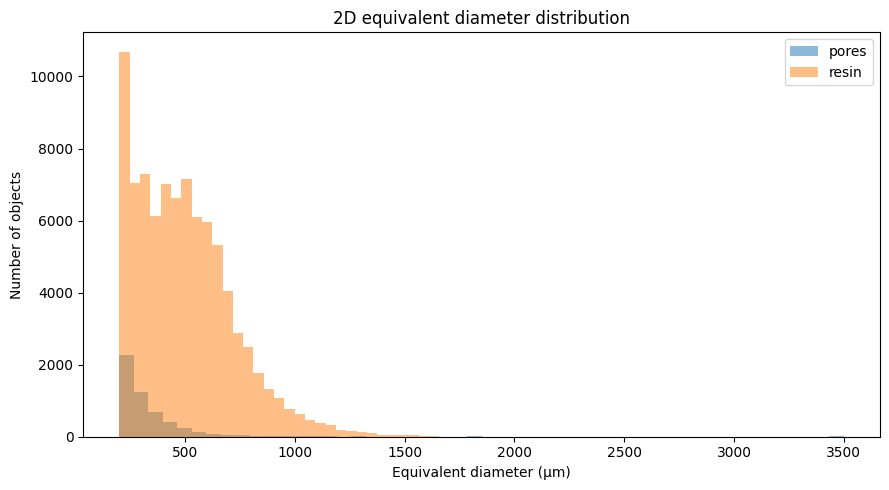

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\components_2d_equivalent_diameter_distribution.png


In [52]:
# ============================================================
# Cell 54 - Save 2D equivalent diameter distribution
# ============================================================

out_path = FIGURES_DIR / "components_2d_equivalent_diameter_distribution.png"

fig, ax = plt.subplots(figsize=(9, 5))

for phase in df_components_2d["phase"].unique():
    df_phase = df_components_2d[df_components_2d["phase"] == phase]
    
    ax.hist(
        df_phase["equivalent_diameter_um"],
        bins=50,
        alpha=0.5,
        label=phase
    )

ax.set_title("2D equivalent diameter distribution")
ax.set_xlabel("Equivalent diameter (µm)")
ax.set_ylabel("Number of objects")
ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

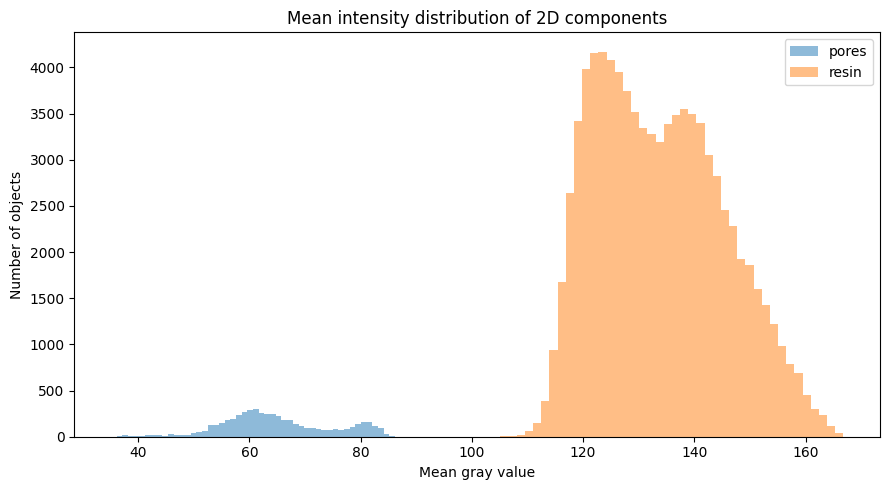

In [53]:
# ============================================================
# Cell 55 - Mean intensity distribution of 2D components
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

for phase in df_components_2d["phase"].unique():
    df_phase = df_components_2d[df_components_2d["phase"] == phase]
    
    ax.hist(
        df_phase["mean_intensity"],
        bins=50,
        alpha=0.5,
        label=phase
    )

ax.set_title("Mean intensity distribution of 2D components")
ax.set_xlabel("Mean gray value")
ax.set_ylabel("Number of objects")
ax.legend()

plt.tight_layout()
plt.show()

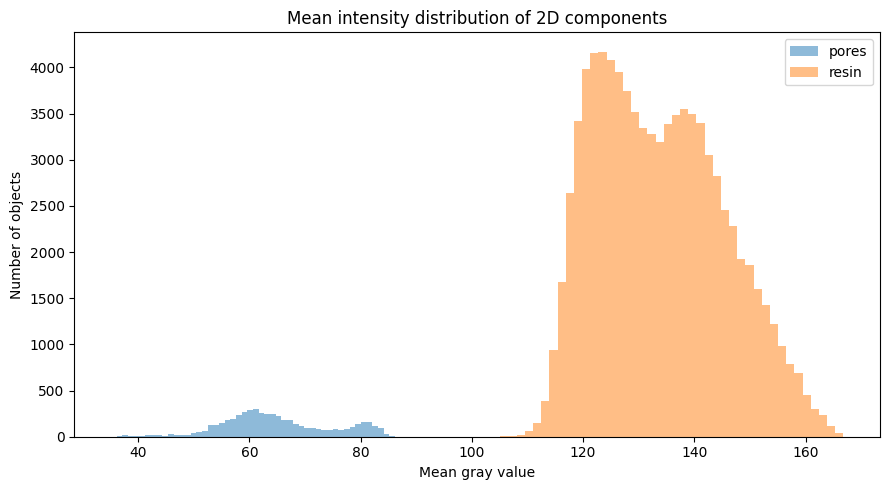

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\components_2d_mean_intensity_distribution.png


In [54]:
# ============================================================
# Cell 56 - Save mean intensity distribution of 2D components
# ============================================================

out_path = FIGURES_DIR / "components_2d_mean_intensity_distribution.png"

fig, ax = plt.subplots(figsize=(9, 5))

for phase in df_components_2d["phase"].unique():
    df_phase = df_components_2d[df_components_2d["phase"] == phase]
    
    ax.hist(
        df_phase["mean_intensity"],
        bins=50,
        alpha=0.5,
        label=phase
    )

ax.set_title("Mean intensity distribution of 2D components")
ax.set_xlabel("Mean gray value")
ax.set_ylabel("Number of objects")
ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

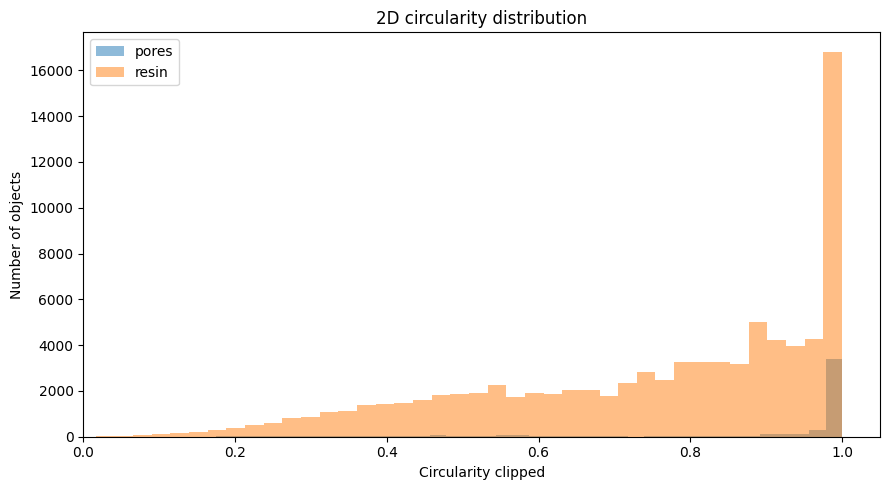

In [55]:
# ============================================================
# Cell 57 - Circularity distribution of 2D components
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

for phase in df_components_2d["phase"].unique():
    df_phase = df_components_2d[df_components_2d["phase"] == phase]
    
    ax.hist(
        df_phase["circularity_clipped"],
        bins=40,
        alpha=0.5,
        label=phase
    )

ax.set_title("2D circularity distribution")
ax.set_xlabel("Circularity clipped")
ax.set_ylabel("Number of objects")
ax.set_xlim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()

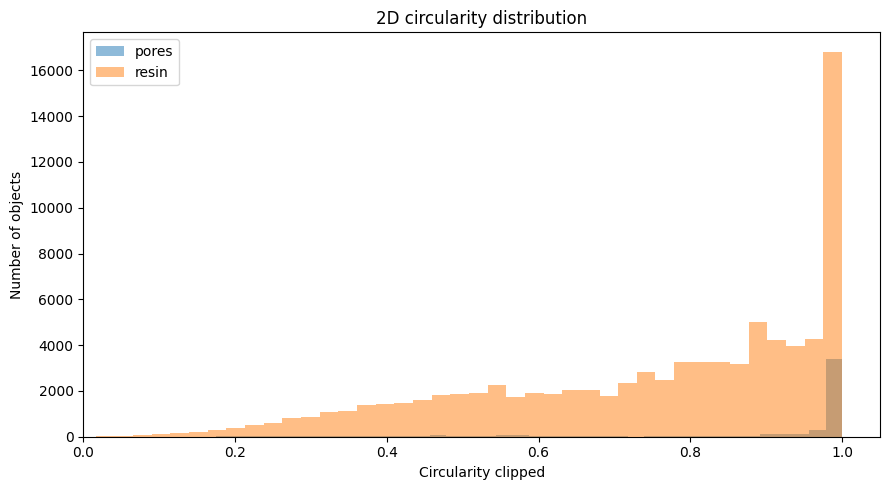

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\components_2d_circularity_distribution.png


In [56]:
# ============================================================
# Cell 58 - Save 2D circularity distribution
# ============================================================

out_path = FIGURES_DIR / "components_2d_circularity_distribution.png"

fig, ax = plt.subplots(figsize=(9, 5))

for phase in df_components_2d["phase"].unique():
    df_phase = df_components_2d[df_components_2d["phase"] == phase]
    
    ax.hist(
        df_phase["circularity_clipped"],
        bins=40,
        alpha=0.5,
        label=phase
    )

ax.set_title("2D circularity distribution")
ax.set_xlabel("Circularity clipped")
ax.set_ylabel("Number of objects")
ax.set_xlim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

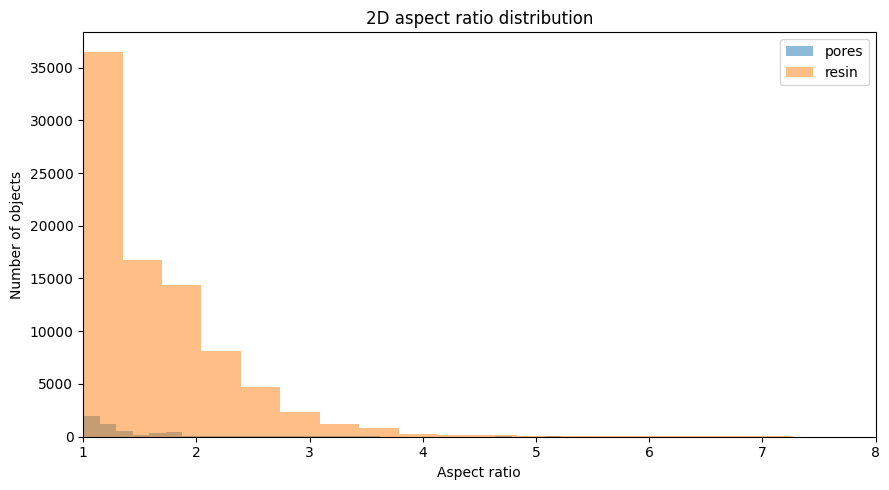

In [57]:
# ============================================================
# Cell 59 - Aspect ratio distribution of 2D components
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

for phase in df_components_2d["phase"].unique():
    df_phase = df_components_2d[df_components_2d["phase"] == phase]
    
    ax.hist(
        df_phase["aspect_ratio"].dropna(),
        bins=50,
        alpha=0.5,
        label=phase
    )

ax.set_title("2D aspect ratio distribution")
ax.set_xlabel("Aspect ratio")
ax.set_ylabel("Number of objects")
ax.set_xlim(1, 8)
ax.legend()

plt.tight_layout()
plt.show()

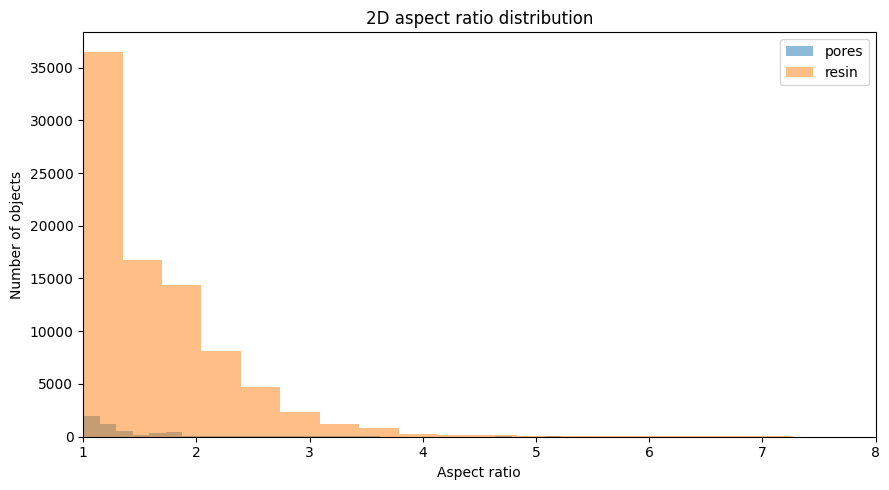

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\components_2d_aspect_ratio_distribution.png


In [58]:
# ============================================================
# Cell 60 - Save 2D aspect ratio distribution
# ============================================================

out_path = FIGURES_DIR / "components_2d_aspect_ratio_distribution.png"

fig, ax = plt.subplots(figsize=(9, 5))

for phase in df_components_2d["phase"].unique():
    df_phase = df_components_2d[df_components_2d["phase"] == phase]
    
    ax.hist(
        df_phase["aspect_ratio"].dropna(),
        bins=50,
        alpha=0.5,
        label=phase
    )

ax.set_title("2D aspect ratio distribution")
ax.set_xlabel("Aspect ratio")
ax.set_ylabel("Number of objects")
ax.set_xlim(1, 8)
ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [60]:
# ============================================================
# Cell 61 - Rule-based morphological classification of 2D components
# ============================================================

def classify_2d_object(row):
    """
    Classify a 2D connected component using simple intensity and morphology rules.

    Classes:
    - small_object: very small components, possibly noise or unresolved objects
    - rounded_pore: dark and relatively rounded pore-like objects
    - elongated_pore: dark and elongated pore-like objects
    - rounded_resin: intermediate-intensity and relatively rounded resin-like objects
    - elongated_resin: intermediate-intensity and elongated resin-like objects
    - irregular_object: objects that do not clearly fit the previous categories
    """

    area = row["area_pixels"]
    phase = row["phase"]
    circularity = row["circularity_clipped"]
    aspect_ratio = row["aspect_ratio"]
    eccentricity = row["eccentricity"]

    # Very small regions are hard to classify reliably
    if area < 10:
        return "small_object"

    # Rounded objects
    is_rounded = (
        circularity >= 0.70 and
        aspect_ratio <= 1.5 and
        eccentricity <= 0.75
    )

    # Elongated objects
    is_elongated = (
        aspect_ratio >= 2.0 or
        eccentricity >= 0.85
    )

    if phase == "pores":
        if is_rounded:
            return "rounded_pore"
        elif is_elongated:
            return "elongated_pore"
        else:
            return "irregular_pore"

    if phase == "resin":
        if is_rounded:
            return "rounded_resin"
        elif is_elongated:
            return "elongated_resin"
        else:
            return "irregular_resin"

    return "unclassified"


df_components_2d["morphology_class_2d"] = df_components_2d.apply(
    classify_2d_object,
    axis=1
)

df_components_2d[[
    "phase",
    "area_pixels",
    "equivalent_diameter_um",
    "circularity_clipped",
    "aspect_ratio",
    "eccentricity",
    "mean_intensity",
    "morphology_class_2d"
]].head()

,phase,area_pixels,equivalent_diameter_um,circularity_clipped,aspect_ratio,eccentricity,mean_intensity,morphology_class_2d
0,pores,7.0,238.832853,0.720235,2.096953,0.878967,82.857143,small_object
1,pores,18.0,382.984589,0.388362,1.280274,0.624427,78.444444,irregular_pore
2,pores,24.0,442.232511,0.369319,2.309641,0.901409,64.166667,elongated_pore
3,pores,52.0,650.948631,0.131100,1.666862,0.800053,80.288462,irregular_pore
4,pores,34.0,526.361971,0.222864,1.084207,0.386396,79.911765,irregular_pore


In [61]:
# ============================================================
# Cell 62 - Summary of 2D morphological classes
# ============================================================

df_morphology_2d_summary = (
    df_components_2d
    .groupby(["phase", "morphology_class_2d"])
    .agg(
        number_of_objects=("label_2d", "count"),
        mean_area_pixels=("area_pixels", "mean"),
        median_area_pixels=("area_pixels", "median"),
        mean_equivalent_diameter_um=("equivalent_diameter_um", "mean"),
        median_equivalent_diameter_um=("equivalent_diameter_um", "median"),
        mean_circularity=("circularity_clipped", "mean"),
        mean_aspect_ratio=("aspect_ratio", "mean"),
        mean_eccentricity=("eccentricity", "mean"),
        mean_intensity=("mean_intensity", "mean")
    )
    .reset_index()
)

df_morphology_2d_summary

,phase,morphology_class_2d,number_of_objects,mean_area_pixels,median_area_pixels,mean_equivalent_diameter_um,median_equivalent_diameter_um,mean_circularity,mean_aspect_ratio,mean_eccentricity,mean_intensity
0,pores,elongated_pore,103,17.009709,12.0,361.257796,312.705608,0.455623,2.642714,0.914226,70.813234
1,pores,irregular_pore,368,30.578804,17.0,429.317487,372.194119,0.434811,1.390757,0.632920,75.808848
2,pores,rounded_pore,2152,58.182621,17.0,510.865683,372.194119,0.981098,1.135516,0.413241,57.866425
3,pores,small_object,2657,6.723749,7.0,232.817941,238.832853,0.882624,1.758407,0.646029,68.913593
4,resin,elongated_resin,17439,56.793279,40.0,623.857165,570.919717,0.543442,2.419783,0.899871,132.619065
5,resin,irregular_resin,21035,45.804944,35.0,570.082115,534.046494,0.626209,1.541572,0.717081,131.802397
6,resin,rounded_resin,32276,34.708080,32.0,514.794020,510.646119,0.923493,1.163130,0.456727,130.491418
7,resin,small_object,15583,6.679651,6.0,232.022373,221.116256,0.785669,1.999444,0.769088,144.749956


In [71]:
# ============================================================
# Cell 63 - Save 2D morphological classification tables
# ============================================================

out_components_csv = RESULTS_DIR / "components_2d_with_morphology_classification.csv"
out_summary_csv = RESULTS_DIR / "morphology_2d_summary.csv"

df_components_2d.to_csv(out_components_csv, index=False)
df_morphology_2d_summary.to_csv(out_summary_csv, index=False)

print(f"2D components with morphology classification saved to: {out_components_csv}")
print(f"2D morphology summary saved to: {out_summary_csv}")

2D components with morphology classification saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\components_2d_with_morphology_classification.csv
2D morphology summary saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\morphology_2d_summary.csv


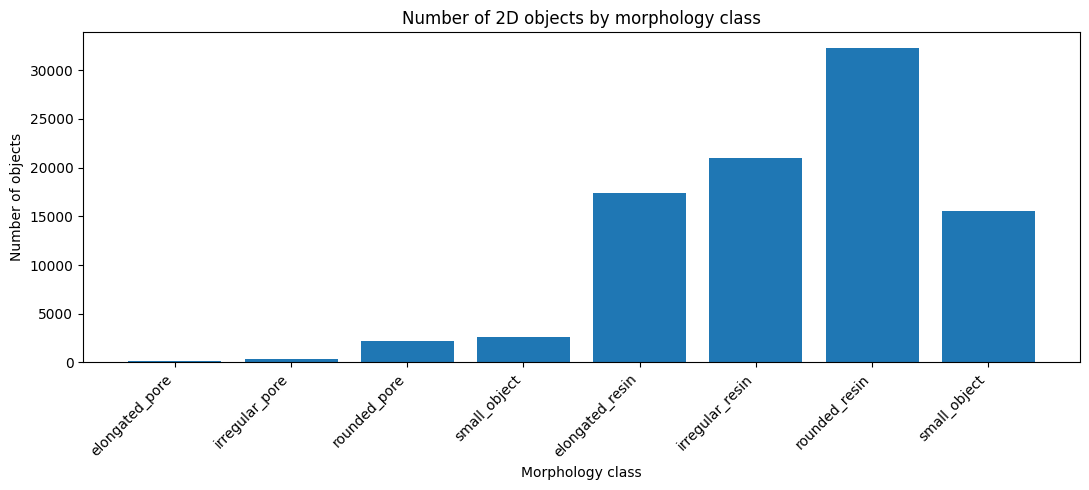

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\morphology_2d_class_counts.png


In [62]:
# ============================================================
# Cell 64 - Plot and save number of objects by 2D morphology class
# ============================================================

out_path = FIGURES_DIR / "morphology_2d_class_counts.png"

class_counts = (
    df_components_2d
    .groupby(["phase", "morphology_class_2d"])
    .size()
    .reset_index(name="number_of_objects")
)

fig, ax = plt.subplots(figsize=(11, 5))

x_labels = class_counts["morphology_class_2d"]
x_positions = np.arange(len(class_counts))

ax.bar(x_positions, class_counts["number_of_objects"])

ax.set_title("Number of 2D objects by morphology class")
ax.set_xlabel("Morphology class")
ax.set_ylabel("Number of objects")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [63]:
# ============================================================
# Cell 65 - Helper function for 3D connected-component analysis
# ============================================================

def analyze_3d_components(mask_3d, intensity_volume, phase_name, min_volume_voxels=20):
    """
    Analyze connected components in a 3D binary mask.

    Parameters
    ----------
    mask_3d : 3D boolean array
        Binary mask for a given phase.
    intensity_volume : 3D array
        Original grayscale volume.
    phase_name : str
        Name of the analyzed phase.
    min_volume_voxels : int
        Minimum object volume in voxels to keep.

    Returns
    -------
    list of dict
        One dictionary per 3D connected component.
    """

    labeled_volume = measure.label(mask_3d, connectivity=3)

    props = measure.regionprops(
        labeled_volume,
        intensity_image=intensity_volume
    )

    rows = []

    for prop in props:
        if prop.area < min_volume_voxels:
            continue

        volume_voxels = prop.area
        volume_mm3 = volume_voxels * voxel_volume_mm3

        # Equivalent sphere diameter:
        # V = (pi / 6) * d^3  ->  d = (6V/pi)^(1/3)
        equivalent_diameter_voxels = (6.0 * volume_voxels / np.pi) ** (1.0 / 3.0)
        equivalent_diameter_um = equivalent_diameter_voxels * VOXEL_SIZE_UM

        centroid_z, centroid_y, centroid_x = prop.centroid

        # Bounding box format in 3D:
        # min_z, min_y, min_x, max_z, max_y, max_x
        min_z, min_y, min_x, max_z, max_y, max_x = prop.bbox

        bbox_z = max_z - min_z
        bbox_y = max_y - min_y
        bbox_x = max_x - min_x

        bbox_lengths = np.array([bbox_z, bbox_y, bbox_x], dtype=float)
        bbox_sorted = np.sort(bbox_lengths)

        shortest_axis = bbox_sorted[0]
        intermediate_axis = bbox_sorted[1]
        longest_axis = bbox_sorted[2]

        if shortest_axis > 0:
            elongation_bbox = longest_axis / shortest_axis
        else:
            elongation_bbox = np.nan

        if intermediate_axis > 0:
            flatness_bbox = longest_axis / intermediate_axis
        else:
            flatness_bbox = np.nan

        bbox_volume_voxels = bbox_z * bbox_y * bbox_x

        if bbox_volume_voxels > 0:
            extent_3d = volume_voxels / bbox_volume_voxels
        else:
            extent_3d = np.nan

        rows.append({
            "phase": phase_name,
            "label_3d": prop.label,

            "volume_voxels": volume_voxels,
            "volume_mm3": volume_mm3,

            "equivalent_diameter_voxels": equivalent_diameter_voxels,
            "equivalent_diameter_um": equivalent_diameter_um,

            "centroid_z_pixels": centroid_z,
            "centroid_y_pixels": centroid_y,
            "centroid_x_pixels": centroid_x,

            "centroid_z_mm": centroid_z * voxel_size_mm,
            "centroid_y_mm": centroid_y * voxel_size_mm,
            "centroid_x_mm": centroid_x * voxel_size_mm,

            "bbox_z_pixels": bbox_z,
            "bbox_y_pixels": bbox_y,
            "bbox_x_pixels": bbox_x,

            "bbox_z_mm": bbox_z * voxel_size_mm,
            "bbox_y_mm": bbox_y * voxel_size_mm,
            "bbox_x_mm": bbox_x * voxel_size_mm,

            "longest_axis_bbox_pixels": longest_axis,
            "intermediate_axis_bbox_pixels": intermediate_axis,
            "shortest_axis_bbox_pixels": shortest_axis,

            "elongation_bbox": elongation_bbox,
            "flatness_bbox": flatness_bbox,
            "extent_3d": extent_3d,

            "mean_intensity": prop.intensity_mean,
            "min_intensity": prop.intensity_min,
            "max_intensity": prop.intensity_max,
        })

    return rows

In [64]:
# ============================================================
# Cell 66 - Run 3D connected-component analysis
# ============================================================

MIN_VOLUME_VOXELS_PORES_3D = 20*4
MIN_VOLUME_VOXELS_RESIN_3D = 20*4

rows_pores_3d = analyze_3d_components(
    mask_3d=pores_mask,
    intensity_volume=volume,
    phase_name="pores",
    min_volume_voxels=MIN_VOLUME_VOXELS_PORES_3D
)

rows_resin_3d = analyze_3d_components(
    mask_3d=resin_mask,
    intensity_volume=volume,
    phase_name="resin",
    min_volume_voxels=MIN_VOLUME_VOXELS_RESIN_3D
)

df_components_3d = pd.DataFrame(rows_pores_3d + rows_resin_3d)

print("3D connected-component analysis completed.")
print("Total number of 3D objects:", len(df_components_3d))

df_components_3d.head()

3D connected-component analysis completed.
Total number of 3D objects: 1989


,phase,label_3d,volume_voxels,volume_mm3,equivalent_diameter_voxels,equivalent_diameter_um,centroid_z_pixels,centroid_y_pixels,centroid_x_pixels,centroid_z_mm,...,bbox_x_mm,longest_axis_bbox_pixels,intermediate_axis_bbox_pixels,shortest_axis_bbox_pixels,elongation_bbox,flatness_bbox,extent_3d,mean_intensity,min_intensity,max_intensity
0,pores,2,95.0,0.048640,5.661198,452.895822,1.957895,1.484211,187.600000,0.156632,...,0.64,8.0,6.0,5.0,1.600000,1.333333,0.395833,80.315789,65.0,87.0
1,pores,4,179.0,0.091648,6.992269,559.381531,2.480447,3.251397,63.413408,0.198436,...,0.88,11.0,8.0,7.0,1.571429,1.375000,0.290584,76.715084,27.0,87.0
2,pores,5,132.0,0.067584,6.317207,505.376554,1.128788,8.007576,149.250000,0.090303,...,1.04,14.0,13.0,5.0,2.800000,1.076923,0.145055,79.696970,31.0,87.0
3,pores,6,149.0,0.076288,6.577526,526.202050,1.322148,10.523490,38.523490,0.105772,...,0.88,14.0,11.0,5.0,2.800000,1.272727,0.193506,77.597315,35.0,87.0
4,pores,7,231.0,0.118272,7.612684,609.014696,3.051948,9.480519,5.077922,0.244156,...,0.96,12.0,10.0,10.0,1.200000,1.200000,0.192500,81.303030,59.0,87.0


In [65]:
# ============================================================
# Cell 67 - Global summary of 3D components by phase
# ============================================================

df_components_3d_summary = df_components_3d.groupby("phase").agg(
    number_of_objects=("label_3d", "count"),

    mean_volume_voxels=("volume_voxels", "mean"),
    median_volume_voxels=("volume_voxels", "median"),
    std_volume_voxels=("volume_voxels", "std"),

    mean_volume_mm3=("volume_mm3", "mean"),
    median_volume_mm3=("volume_mm3", "median"),

    mean_equivalent_diameter_um=("equivalent_diameter_um", "mean"),
    median_equivalent_diameter_um=("equivalent_diameter_um", "median"),
    std_equivalent_diameter_um=("equivalent_diameter_um", "std"),

    mean_elongation_bbox=("elongation_bbox", "mean"),
    median_elongation_bbox=("elongation_bbox", "median"),

    mean_extent_3d=("extent_3d", "mean"),
    median_extent_3d=("extent_3d", "median"),

    mean_intensity=("mean_intensity", "mean"),
    median_intensity=("mean_intensity", "median")
)

df_components_3d_summary

,number_of_objects,mean_volume_voxels,median_volume_voxels,std_volume_voxels,mean_volume_mm3,median_volume_mm3,mean_equivalent_diameter_um,median_equivalent_diameter_um,std_equivalent_diameter_um,mean_elongation_bbox,median_elongation_bbox,mean_extent_3d,median_extent_3d,mean_intensity,median_intensity
phase,,,,,,,,,,,,,,,
pores,232,536.232759,125.0,3249.312729,0.274551,0.064000,570.020004,496.280393,305.929826,1.272622,1.166667,0.435776,0.492470,61.922860,58.269509
resin,1757,1810.328970,236.0,54766.772829,0.926888,0.120832,686.088833,613.377414,389.979221,1.499497,1.363636,0.324337,0.322751,132.133508,130.658038


In [76]:
# ============================================================
# Cell 68 - Save 3D connected-component tables
# ============================================================

out_components_csv = RESULTS_DIR / "components_3d.csv"
out_summary_csv = RESULTS_DIR / "components_3d_summary_by_phase.csv"

df_components_3d.to_csv(out_components_csv, index=False)
df_components_3d_summary.to_csv(out_summary_csv)

print(f"3D components table saved to: {out_components_csv}")
print(f"3D components summary saved to: {out_summary_csv}")

3D components table saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\components_3d.csv
3D components summary saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\components_3d_summary_by_phase.csv


In [66]:
# ============================================================
# Cell 69 - Rule-based morphological classification of 3D components
# ============================================================

def classify_3d_object(row):
    """
    Classify a 3D connected component using simple volume and morphology rules.

    Classes:
    - small_3d_object: very small 3D objects, possibly noise or unresolved objects
    - compact_pore: dark, compact pore-like object
    - elongated_pore: dark, elongated pore-like object
    - compact_resin: intermediate-intensity, compact resin-like object
    - elongated_resin: intermediate-intensity, elongated resin-like object
    - irregular_pore / irregular_resin: objects that do not clearly fit compact or elongated criteria
    """

    phase = row["phase"]
    volume_voxels = row["volume_voxels"]
    elongation = row["elongation_bbox"]
    extent = row["extent_3d"]

    # Very small 3D objects are difficult to classify reliably
    if volume_voxels < 50:
        return "small_3d_object"

    # Compact objects: low elongation and relatively high filling of bounding box
    is_compact = (
        elongation <= 1.5 and
        extent >= 0.35
    )

    # Elongated or spatially extended objects
    is_elongated = (
        elongation >= 2.0 or
        extent < 0.20
    )

    if phase == "pores":
        if is_compact:
            return "compact_pore"
        elif is_elongated:
            return "elongated_pore"
        else:
            return "irregular_pore"

    if phase == "resin":
        if is_compact:
            return "compact_resin"
        elif is_elongated:
            return "elongated_resin"
        else:
            return "irregular_resin"

    return "unclassified"


df_components_3d["morphology_class_3d"] = df_components_3d.apply(
    classify_3d_object,
    axis=1
)

df_components_3d[[
    "phase",
    "volume_voxels",
    "equivalent_diameter_um",
    "elongation_bbox",
    "extent_3d",
    "mean_intensity",
    "morphology_class_3d"
]].head()

,phase,volume_voxels,equivalent_diameter_um,elongation_bbox,extent_3d,mean_intensity,morphology_class_3d
0,pores,95.0,452.895822,1.600000,0.395833,80.315789,irregular_pore
1,pores,179.0,559.381531,1.571429,0.290584,76.715084,irregular_pore
2,pores,132.0,505.376554,2.800000,0.145055,79.696970,elongated_pore
3,pores,149.0,526.202050,2.800000,0.193506,77.597315,elongated_pore
4,pores,231.0,609.014696,1.200000,0.192500,81.303030,elongated_pore


In [67]:
# ============================================================
# Cell 70 - Summary of 3D morphological classes
# ============================================================

df_morphology_3d_summary = (
    df_components_3d
    .groupby(["phase", "morphology_class_3d"])
    .agg(
        number_of_objects=("label_3d", "count"),
        mean_volume_voxels=("volume_voxels", "mean"),
        median_volume_voxels=("volume_voxels", "median"),
        mean_volume_mm3=("volume_mm3", "mean"),
        median_volume_mm3=("volume_mm3", "median"),
        mean_equivalent_diameter_um=("equivalent_diameter_um", "mean"),
        median_equivalent_diameter_um=("equivalent_diameter_um", "median"),
        mean_elongation_bbox=("elongation_bbox", "mean"),
        median_elongation_bbox=("elongation_bbox", "median"),
        mean_extent_3d=("extent_3d", "mean"),
        median_extent_3d=("extent_3d", "median"),
        mean_intensity=("mean_intensity", "mean")
    )
    .reset_index()
)

df_morphology_3d_summary

,phase,morphology_class_3d,number_of_objects,mean_volume_voxels,median_volume_voxels,mean_volume_mm3,median_volume_mm3,mean_equivalent_diameter_um,median_equivalent_diameter_um,mean_elongation_bbox,median_elongation_bbox,mean_extent_3d,median_extent_3d,mean_intensity
0,pores,compact_pore,163,676.484663,128.0,0.346360,0.065536,593.886358,500.219291,1.127750,1.142857,0.521419,0.518519,57.011178
1,pores,elongated_pore,38,130.552632,120.5,0.066843,0.061696,495.675103,490.138529,1.746742,1.472222,0.177875,0.166180,74.044321
2,pores,irregular_pore,31,296.064516,112.0,0.151585,0.057344,535.661630,478.442540,1.453191,1.500000,0.301599,0.265306,72.890241
3,resin,compact_resin,590,204.659322,178.0,0.104786,0.091136,568.803458,558.337906,1.202960,1.166667,0.454063,0.444444,131.641836
4,resin,elongated_resin,534,5371.011236,540.5,2.749958,0.276736,880.814284,808.516656,1.888721,1.735088,0.208609,0.176734,131.458963
5,resin,irregular_resin,633,303.126382,231.0,0.155201,0.118272,631.136195,609.014696,1.447539,1.428571,0.301051,0.290043,133.160828


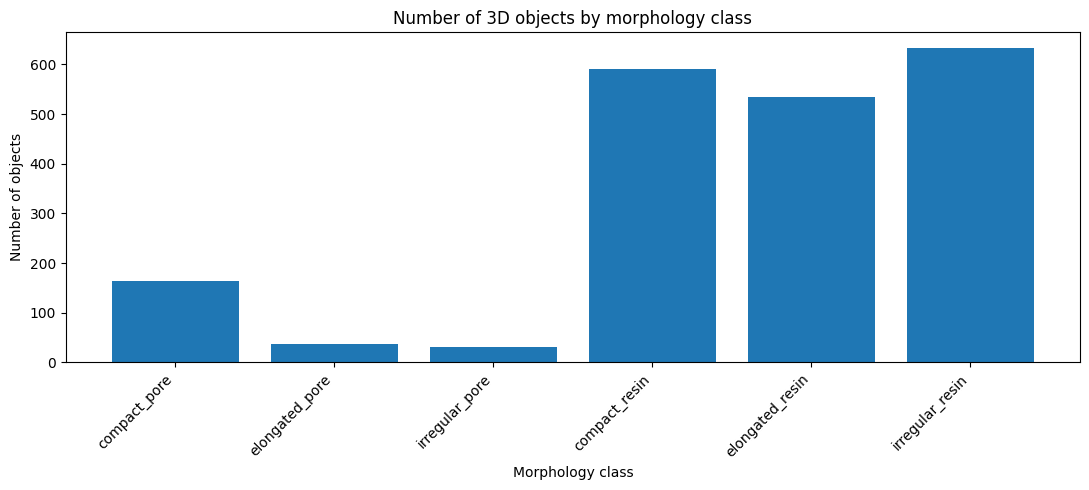

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\morphology_3d_class_counts.png


In [68]:
# ============================================================
# Cell 71 - Plot and save number of 3D objects by morphology class
# ============================================================

out_path = FIGURES_DIR / "morphology_3d_class_counts.png"

class_counts_3d = (
    df_components_3d
    .groupby(["phase", "morphology_class_3d"])
    .size()
    .reset_index(name="number_of_objects")
)

fig, ax = plt.subplots(figsize=(11, 5))

x_labels = class_counts_3d["morphology_class_3d"]
x_positions = np.arange(len(class_counts_3d))

ax.bar(x_positions, class_counts_3d["number_of_objects"])

ax.set_title("Number of 3D objects by morphology class")
ax.set_xlabel("Morphology class")
ax.set_ylabel("Number of objects")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [80]:
# ============================================================
# Cell 72 - Save 3D morphological classification tables
# ============================================================

out_components_csv = RESULTS_DIR / "components_3d_with_morphology_classification.csv"
out_summary_csv = RESULTS_DIR / "morphology_3d_summary.csv"

df_components_3d.to_csv(out_components_csv, index=False)
df_morphology_3d_summary.to_csv(out_summary_csv, index=False)

print(f"3D components with morphology classification saved to: {out_components_csv}")
print(f"3D morphology summary saved to: {out_summary_csv}")

3D components with morphology classification saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\components_3d_with_morphology_classification.csv
3D morphology summary saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\morphology_3d_summary.csv


In [69]:
# ============================================================
# Cell 73 - Detailed statistics for 3D resin morphology classes
# ============================================================

df_resin_3d = df_components_3d[df_components_3d["phase"] == "resin"].copy()

df_resin_morphology_stats = (
    df_resin_3d
    .groupby("morphology_class_3d")
    .agg(
        number_of_objects=("label_3d", "count"),
        
        mean_volume_voxels=("volume_voxels", "mean"),
        median_volume_voxels=("volume_voxels", "median"),
        max_volume_voxels=("volume_voxels", "max"),
        
        mean_equivalent_diameter_um=("equivalent_diameter_um", "mean"),
        median_equivalent_diameter_um=("equivalent_diameter_um", "median"),
        
        mean_elongation_bbox=("elongation_bbox", "mean"),
        median_elongation_bbox=("elongation_bbox", "median"),
        max_elongation_bbox=("elongation_bbox", "max"),
        
        mean_extent_3d=("extent_3d", "mean"),
        median_extent_3d=("extent_3d", "median"),
        min_extent_3d=("extent_3d", "min"),
        
        mean_intensity=("mean_intensity", "mean"),
        median_intensity=("mean_intensity", "median")
    )
    .reset_index()
)

df_resin_morphology_stats

,morphology_class_3d,number_of_objects,mean_volume_voxels,median_volume_voxels,max_volume_voxels,mean_equivalent_diameter_um,median_equivalent_diameter_um,mean_elongation_bbox,median_elongation_bbox,max_elongation_bbox,mean_extent_3d,median_extent_3d,min_extent_3d,mean_intensity,median_intensity
0,compact_resin,590,204.659322,178.0,1011.0,568.803458,558.337906,1.202960,1.166667,1.500000,0.454063,0.444444,0.35000,131.641836,129.685507
1,elongated_resin,534,5371.011236,540.5,2295340.0,880.814284,808.516656,1.888721,1.735088,6.250000,0.208609,0.176734,0.03864,131.458963,130.223033
2,irregular_resin,633,303.126382,231.0,1882.0,631.136195,609.014696,1.447539,1.428571,1.916667,0.301051,0.290043,0.20000,133.160828,132.180000


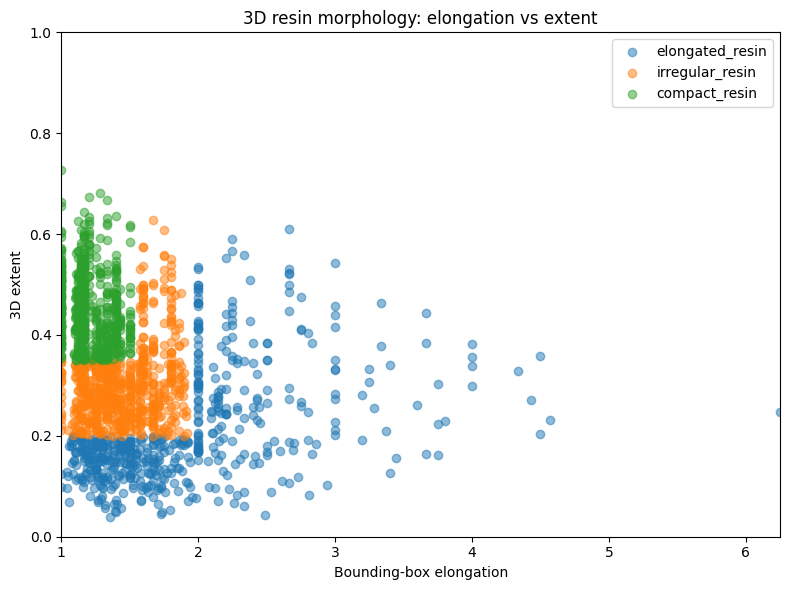

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\resin_3d_elongation_vs_extent.png


In [70]:
# ============================================================
# Cell 74 - Plot and save resin 3D morphology comparison
# ============================================================

out_path = FIGURES_DIR / "resin_3d_elongation_vs_extent.png"

fig, ax = plt.subplots(figsize=(8, 6))

for morphology_class in df_resin_3d["morphology_class_3d"].unique():
    df_class = df_resin_3d[df_resin_3d["morphology_class_3d"] == morphology_class]
    
    ax.scatter(
        df_class["elongation_bbox"],
        df_class["extent_3d"],
        alpha=0.5,
        label=morphology_class
    )

ax.set_title("3D resin morphology: elongation vs extent")
ax.set_xlabel("Bounding-box elongation")
ax.set_ylabel("3D extent")
ax.set_xlim(1, min(8, df_resin_3d["elongation_bbox"].max()))
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [71]:
# ============================================================
# Cell 75 - Select representative 3D resin objects by morphology class
# ============================================================

df_resin_3d = df_components_3d[df_components_3d["phase"] == "resin"].copy()

features_for_selection = [
    "volume_voxels",
    "equivalent_diameter_um",
    "elongation_bbox",
    "extent_3d",
    "mean_intensity"
]

representative_rows = []

for morphology_class in sorted(df_resin_3d["morphology_class_3d"].unique()):
    df_class = df_resin_3d[df_resin_3d["morphology_class_3d"] == morphology_class].copy()
    
    if len(df_class) == 0:
        continue
    
    # Median feature vector for the class
    median_values = df_class[features_for_selection].median()
    
    # Normalize differences by class standard deviation
    std_values = df_class[features_for_selection].std().replace(0, np.nan)
    
    normalized_distance = (
        (df_class[features_for_selection] - median_values) / std_values
    ) ** 2
    
    # If a std is zero or NaN, ignore that feature in the distance
    normalized_distance = normalized_distance.fillna(0)
    
    df_class["distance_to_class_median"] = normalized_distance.sum(axis=1)
    
    # Select the object closest to the class median
    representative_object = df_class.sort_values("distance_to_class_median").iloc[0]
    
    representative_rows.append(representative_object)

df_representative_resin_3d = pd.DataFrame(representative_rows)

selected_columns = [
    "phase",
    "label_3d",
    "morphology_class_3d",
    "volume_voxels",
    "equivalent_diameter_um",
    "elongation_bbox",
    "extent_3d",
    "mean_intensity",
    "centroid_z_pixels",
    "centroid_y_pixels",
    "centroid_x_pixels",
    "centroid_z_mm",
    "centroid_y_mm",
    "centroid_x_mm",
    "distance_to_class_median"
]

df_representative_resin_3d[selected_columns]

,phase,label_3d,morphology_class_3d,volume_voxels,equivalent_diameter_um,elongation_bbox,extent_3d,mean_intensity,centroid_z_pixels,centroid_y_pixels,centroid_x_pixels,centroid_z_mm,centroid_y_mm,centroid_x_mm,distance_to_class_median
261,resin,1976,compact_resin,171.0,550.920775,1.142857,0.436224,129.538012,18.877193,66.953216,88.807018,1.510175,5.356257,7.104561,0.051977
329,resin,2781,elongated_resin,734.0,895.342362,1.583333,0.189370,130.658038,46.895095,17.843324,120.044959,3.751608,1.427466,9.603597,0.084926
594,resin,4797,irregular_resin,189.0,569.610143,1.428571,0.300000,131.243386,108.476190,64.201058,144.407407,8.678095,5.136085,11.552593,0.133604


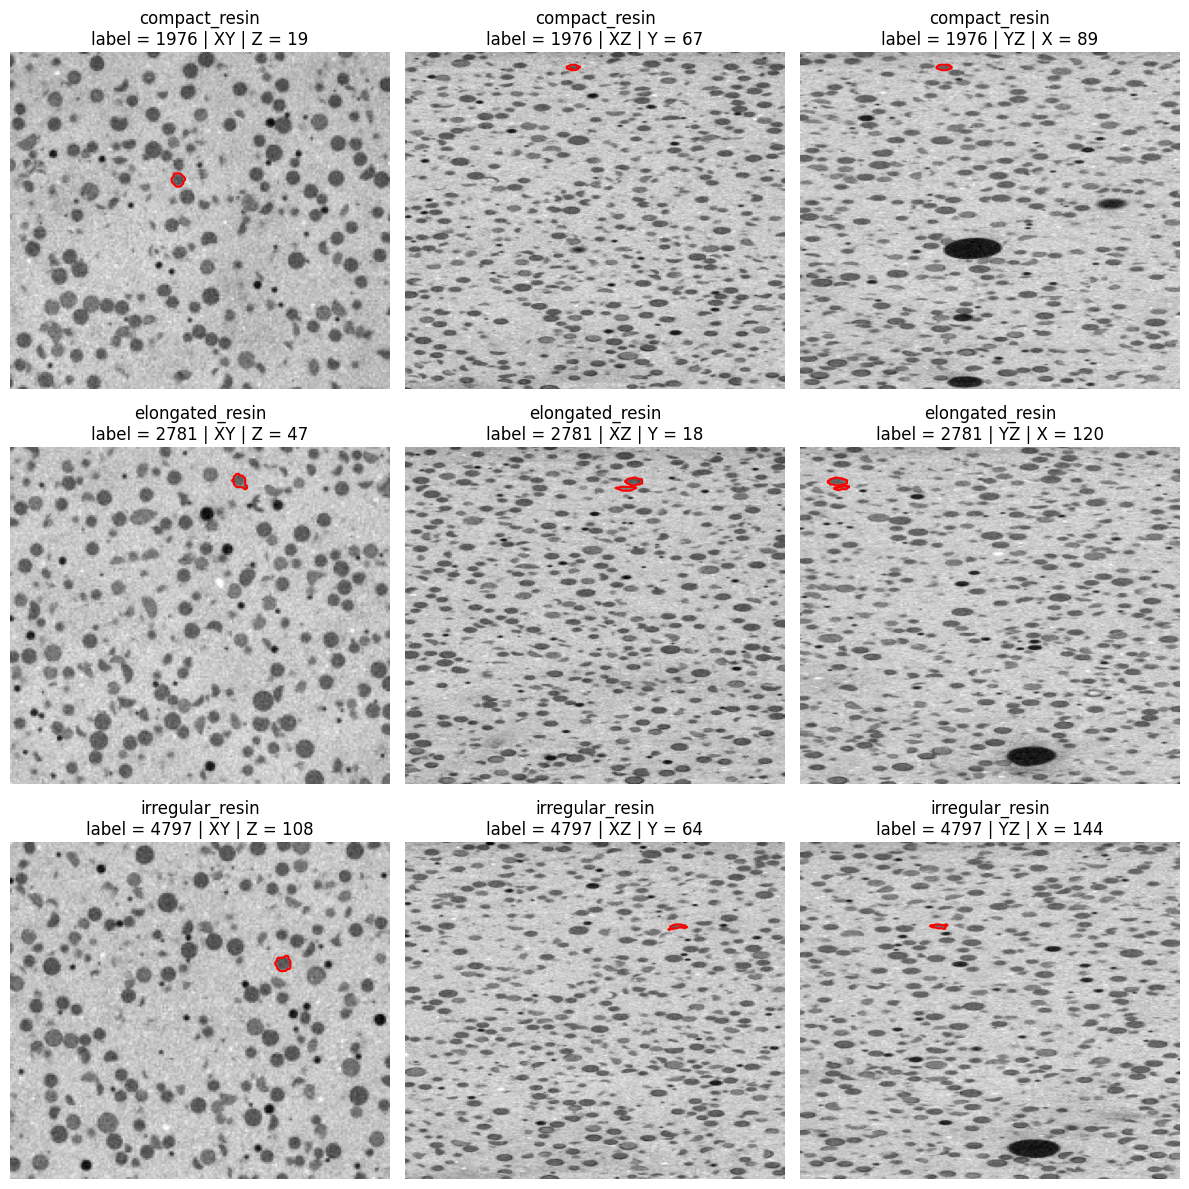

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\representative_3d_resin_objects_orthogonal_views.png


In [78]:
# ============================================================
# Cell 76 - Visualize representative 3D resin objects
# ============================================================

# Re-label the full 3D resin mask so we can isolate individual objects
resin_labeled_3d = measure.label(resin_mask, connectivity=3)

out_path = FIGURES_DIR / "representative_3d_resin_objects_orthogonal_views.png"

n_objects = len(df_representative_resin_3d)

fig, axes = plt.subplots(n_objects, 3, figsize=(12, 4 * n_objects))

if n_objects == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (_, obj) in enumerate(df_representative_resin_3d.iterrows()):
    
    label_id = int(obj["label_3d"])
    morphology_class = obj["morphology_class_3d"]
    
    cz = int(round(obj["centroid_z_pixels"]))
    cy = int(round(obj["centroid_y_pixels"]))
    cx = int(round(obj["centroid_x_pixels"]))
    
    # Individual object mask
    object_mask = resin_labeled_3d == label_id
    
    # Orthogonal slices through the object centroid
    xy_original = volume[cz, :, :]
    xz_original = volume[:, cy, :]
    yz_original = volume[:, :, cx]
    
    xy_object = object_mask[cz, :, :]
    xz_object = object_mask[:, cy, :]
    yz_object = object_mask[:, :, cx]
    
    views = [
        (xy_original, xy_object, f"XY | Z = {cz}"),
        (xz_original, xz_object, f"XZ | Y = {cy}"),
        (yz_original, yz_object, f"YZ | X = {cx}")
    ]
    
    for col_idx, (original_view, object_view, title) in enumerate(views):
        ax = axes[row_idx, col_idx]
        
        ax.imshow(original_view, cmap="gray", aspect="auto")
        ax.contour(object_view, colors="red", levels=[0.5], linewidths=1.5)
        
        ax.set_title(
            f"{morphology_class}\n"
            f"label = {label_id} | {title}"
        )
        ax.axis("off")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [73]:
# ============================================================
# Cell 77 - Select representative 3D pore objects by morphology class
# ============================================================

df_pores_3d = df_components_3d[df_components_3d["phase"] == "pores"].copy()

features_for_selection = [
    "volume_voxels",
    "equivalent_diameter_um",
    "elongation_bbox",
    "extent_3d",
    "mean_intensity"
]

representative_rows = []

for morphology_class in sorted(df_pores_3d["morphology_class_3d"].unique()):
    df_class = df_pores_3d[df_pores_3d["morphology_class_3d"] == morphology_class].copy()
    
    if len(df_class) == 0:
        continue
    
    median_values = df_class[features_for_selection].median()
    std_values = df_class[features_for_selection].std().replace(0, np.nan)
    
    normalized_distance = (
        (df_class[features_for_selection] - median_values) / std_values
    ) ** 2
    
    normalized_distance = normalized_distance.fillna(0)
    
    df_class["distance_to_class_median"] = normalized_distance.sum(axis=1)
    
    representative_object = df_class.sort_values("distance_to_class_median").iloc[0]
    representative_rows.append(representative_object)

df_representative_pores_3d = pd.DataFrame(representative_rows)

selected_columns = [
    "phase",
    "label_3d",
    "morphology_class_3d",
    "volume_voxels",
    "equivalent_diameter_um",
    "elongation_bbox",
    "extent_3d",
    "mean_intensity",
    "centroid_z_pixels",
    "centroid_y_pixels",
    "centroid_x_pixels",
    "centroid_z_mm",
    "centroid_y_mm",
    "centroid_x_mm",
    "distance_to_class_median"
]

df_representative_pores_3d[selected_columns]

,phase,label_3d,morphology_class_3d,volume_voxels,equivalent_diameter_um,elongation_bbox,extent_3d,mean_intensity,centroid_z_pixels,centroid_y_pixels,centroid_x_pixels,centroid_z_mm,centroid_y_mm,centroid_x_mm,distance_to_class_median
119,pores,5028,compact_pore,152.0,529.710167,1.166667,0.517007,57.644737,185.822368,54.486842,126.710526,14.865789,4.358947,10.136842,0.051311
218,pores,14136,elongated_pore,114.0,481.273627,1.428571,0.180952,75.789474,407.473684,27.315789,80.850877,32.597895,2.185263,6.468070,0.106593
17,pores,42,irregular_pore,84.0,434.693896,1.500000,0.222222,81.273810,2.083333,47.809524,191.940476,0.166667,3.824762,15.355238,0.275696


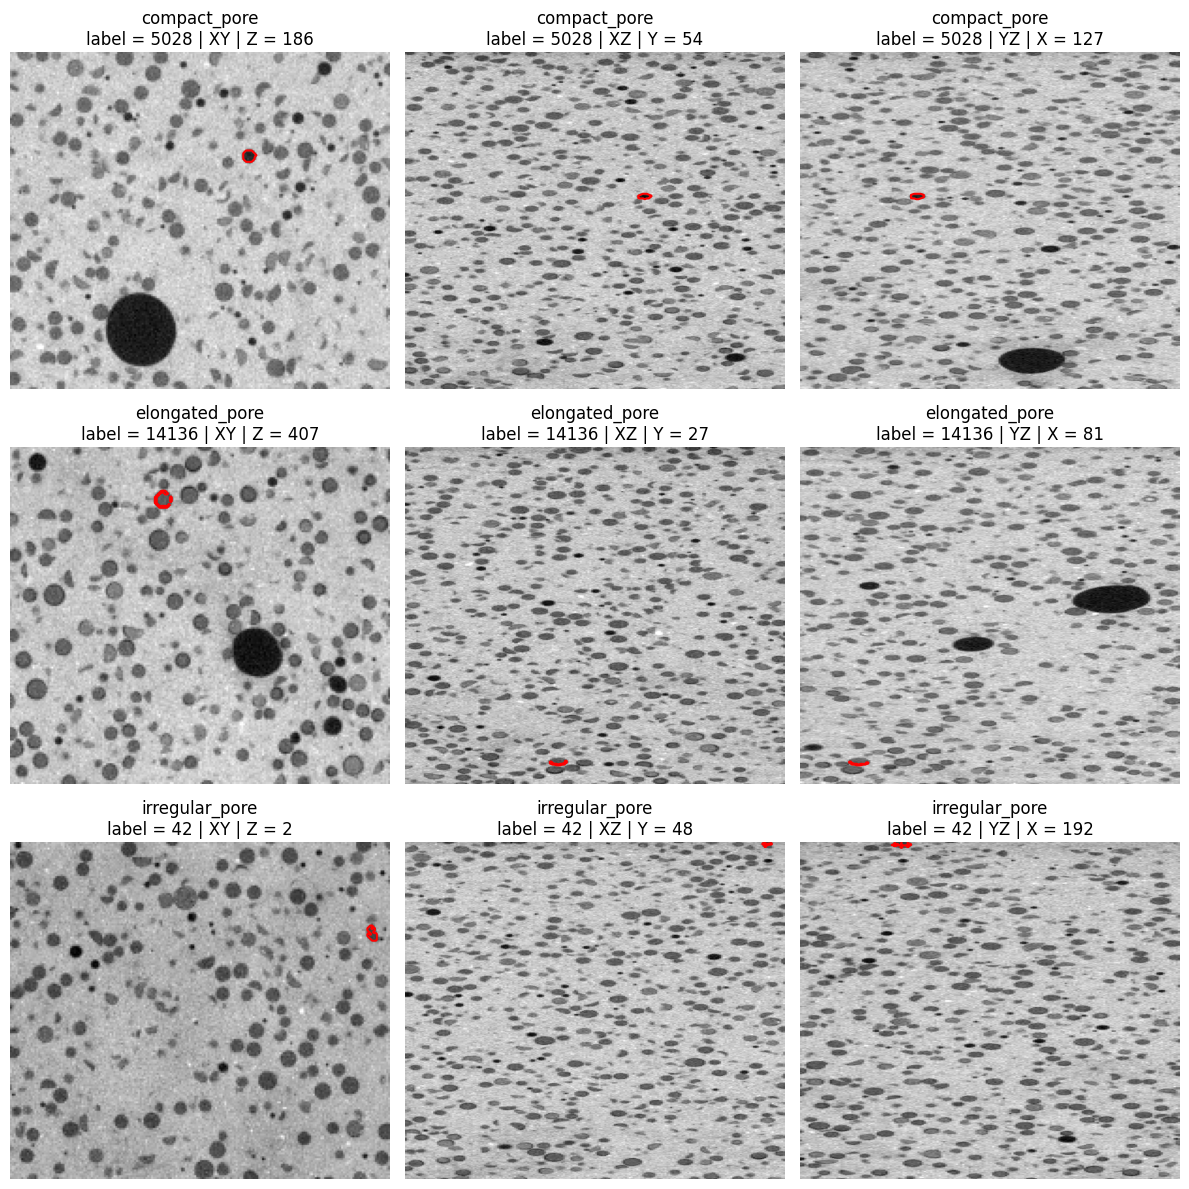

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\representative_3d_pore_objects_orthogonal_views.png


In [77]:
# ============================================================
# Cell 78 - Visualize representative 3D pore objects
# ============================================================

pores_labeled_3d = measure.label(pores_mask, connectivity=3)

out_path = FIGURES_DIR / "representative_3d_pore_objects_orthogonal_views.png"

n_objects = len(df_representative_pores_3d)

fig, axes = plt.subplots(n_objects, 3, figsize=(12, 4 * n_objects))

if n_objects == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (_, obj) in enumerate(df_representative_pores_3d.iterrows()):
    
    label_id = int(obj["label_3d"])
    morphology_class = obj["morphology_class_3d"]
    
    cz = int(round(obj["centroid_z_pixels"]))
    cy = int(round(obj["centroid_y_pixels"]))
    cx = int(round(obj["centroid_x_pixels"]))
    
    object_mask = pores_labeled_3d == label_id
    
    xy_original = volume[cz, :, :]
    xz_original = volume[:, cy, :]
    yz_original = volume[:, :, cx]
    
    xy_object = object_mask[cz, :, :]
    xz_object = object_mask[:, cy, :]
    yz_object = object_mask[:, :, cx]
    
    views = [
        (xy_original, xy_object, f"XY | Z = {cz}"),
        (xz_original, xz_object, f"XZ | Y = {cy}"),
        (yz_original, yz_object, f"YZ | X = {cx}")
    ]
    
    for col_idx, (original_view, object_view, title) in enumerate(views):
        ax = axes[row_idx, col_idx]
        
        ax.imshow(original_view, cmap="gray", aspect="auto")
        ax.contour(object_view, colors="red", levels=[0.5], linewidths=1.5)
        
        ax.set_title(
            f"{morphology_class}\n"
            f"label = {label_id} | {title}"
        )
        ax.axis("off")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [79]:
# ============================================================
# Cell 79 - Add inertia-based 3D shape descriptors
# ============================================================

def compute_inertia_shape_descriptors(mask_3d):
    """
    Compute inertia-based shape descriptors for a 3D binary object.

    The descriptors are based on the eigenvalues of the covariance matrix
    of the object's voxel coordinates.

    Returns
    -------
    dict
        Dictionary with principal-axis ratios.
    """

    coords = np.argwhere(mask_3d)

    if coords.shape[0] < 3:
        return {
            "axis_ratio_3d": np.nan,
            "axis_ratio_intermediate_3d": np.nan,
            "axis_ratio_minor_3d": np.nan
        }

    # Center coordinates
    coords_centered = coords - coords.mean(axis=0)

    # Covariance matrix of voxel coordinates
    cov_matrix = np.cov(coords_centered, rowvar=False)

    # Eigenvalues sorted from largest to smallest
    eigenvalues = np.linalg.eigvalsh(cov_matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]

    # Avoid numerical issues
    eigenvalues = np.maximum(eigenvalues, 0)

    axis_lengths = np.sqrt(eigenvalues)

    major_axis = axis_lengths[0]
    intermediate_axis = axis_lengths[1]
    minor_axis = axis_lengths[2]

    if minor_axis > 0:
        axis_ratio_3d = major_axis / minor_axis
    else:
        axis_ratio_3d = np.nan

    if intermediate_axis > 0:
        axis_ratio_intermediate_3d = major_axis / intermediate_axis
    else:
        axis_ratio_intermediate_3d = np.nan

    if major_axis > 0:
        axis_ratio_minor_3d = minor_axis / major_axis
    else:
        axis_ratio_minor_3d = np.nan

    return {
        "axis_ratio_3d": axis_ratio_3d,
        "axis_ratio_intermediate_3d": axis_ratio_intermediate_3d,
        "axis_ratio_minor_3d": axis_ratio_minor_3d
    }


print("Inertia-based shape descriptor function created.")

Inertia-based shape descriptor function created.


In [80]:
# ============================================================
# Cell 80 - Compute inertia-based descriptors for all 3D objects
# ============================================================

# Make sure labeled volumes are available
pores_labeled_3d = measure.label(pores_mask, connectivity=3)
resin_labeled_3d = measure.label(resin_mask, connectivity=3)

axis_ratio_rows = []

for _, row in df_components_3d.iterrows():
    phase = row["phase"]
    label_id = int(row["label_3d"])

    if phase == "pores":
        object_mask = pores_labeled_3d == label_id
    elif phase == "resin":
        object_mask = resin_labeled_3d == label_id
    else:
        continue

    descriptors = compute_inertia_shape_descriptors(object_mask)

    axis_ratio_rows.append({
        "phase": phase,
        "label_3d": label_id,
        **descriptors
    })

df_axis_ratios_3d = pd.DataFrame(axis_ratio_rows)

df_components_3d = df_components_3d.merge(
    df_axis_ratios_3d,
    on=["phase", "label_3d"],
    how="left"
)

df_components_3d[[
    "phase",
    "label_3d",
    "volume_voxels",
    "elongation_bbox",
    "axis_ratio_3d",
    "axis_ratio_intermediate_3d",
    "axis_ratio_minor_3d"
]].head()

,phase,label_3d,volume_voxels,elongation_bbox,axis_ratio_3d,axis_ratio_intermediate_3d,axis_ratio_minor_3d
0,pores,2,95.0,1.600000,1.451483,1.082114,0.688951
1,pores,4,179.0,1.571429,1.626785,1.317023,0.614709
2,pores,5,132.0,2.800000,3.023714,1.716763,0.330719
3,pores,6,149.0,2.800000,3.752769,1.749971,0.266470
4,pores,7,231.0,1.200000,2.404099,2.005649,0.415956


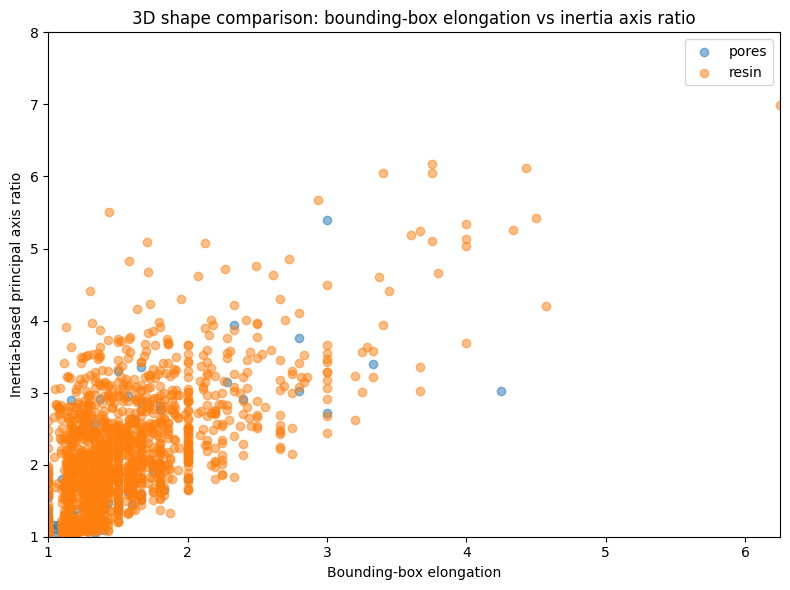

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\bbox_elongation_vs_inertia_axis_ratio_3d.png


In [81]:
# ============================================================
# Cell 81 - Plot and save bbox elongation vs inertia-based axis ratio
# ============================================================

out_path = FIGURES_DIR / "bbox_elongation_vs_inertia_axis_ratio_3d.png"

fig, ax = plt.subplots(figsize=(8, 6))

for phase in df_components_3d["phase"].unique():
    df_phase = df_components_3d[df_components_3d["phase"] == phase]

    ax.scatter(
        df_phase["elongation_bbox"],
        df_phase["axis_ratio_3d"],
        alpha=0.5,
        label=phase
    )

ax.set_title("3D shape comparison: bounding-box elongation vs inertia axis ratio")
ax.set_xlabel("Bounding-box elongation")
ax.set_ylabel("Inertia-based principal axis ratio")

ax.set_xlim(1, min(8, df_components_3d["elongation_bbox"].max()))
ax.set_ylim(1, min(8, df_components_3d["axis_ratio_3d"].max()))

ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [82]:
# ============================================================
# Cell 82 - Inertia-based 3D morphological classification
# ============================================================

def classify_3d_object_inertia(row):
    """
    Classify 3D objects using inertia-based principal-axis ratio.

    This classification is less dependent on integer bounding-box dimensions.
    """

    phase = row["phase"]
    volume_voxels = row["volume_voxels"]
    axis_ratio = row["axis_ratio_3d"]
    extent = row["extent_3d"]

    if volume_voxels < 50:
        return "small_3d_object"

    if np.isnan(axis_ratio):
        return "unclassified"

    is_rounded = (
        axis_ratio <= 1.6 and
        extent >= 0.30
    )

    is_elongated = (
        axis_ratio >= 2.5 or
        extent < 0.18
    )

    if phase == "pores":
        if is_rounded:
            return "rounded_pore_inertia"
        elif is_elongated:
            return "elongated_pore_inertia"
        else:
            return "irregular_pore_inertia"

    if phase == "resin":
        if is_rounded:
            return "rounded_resin_inertia"
        elif is_elongated:
            return "elongated_resin_inertia"
        else:
            return "irregular_resin_inertia"

    return "unclassified"


df_components_3d["morphology_class_3d_inertia"] = df_components_3d.apply(
    classify_3d_object_inertia,
    axis=1
)

df_components_3d[[
    "phase",
    "volume_voxels",
    "elongation_bbox",
    "axis_ratio_3d",
    "extent_3d",
    "morphology_class_3d",
    "morphology_class_3d_inertia"
]].head()

,phase,volume_voxels,elongation_bbox,axis_ratio_3d,extent_3d,morphology_class_3d,morphology_class_3d_inertia
0,pores,95.0,1.600000,1.451483,0.395833,irregular_pore,rounded_pore_inertia
1,pores,179.0,1.571429,1.626785,0.290584,irregular_pore,irregular_pore_inertia
2,pores,132.0,2.800000,3.023714,0.145055,elongated_pore,elongated_pore_inertia
3,pores,149.0,2.800000,3.752769,0.193506,elongated_pore,elongated_pore_inertia
4,pores,231.0,1.200000,2.404099,0.192500,elongated_pore,irregular_pore_inertia


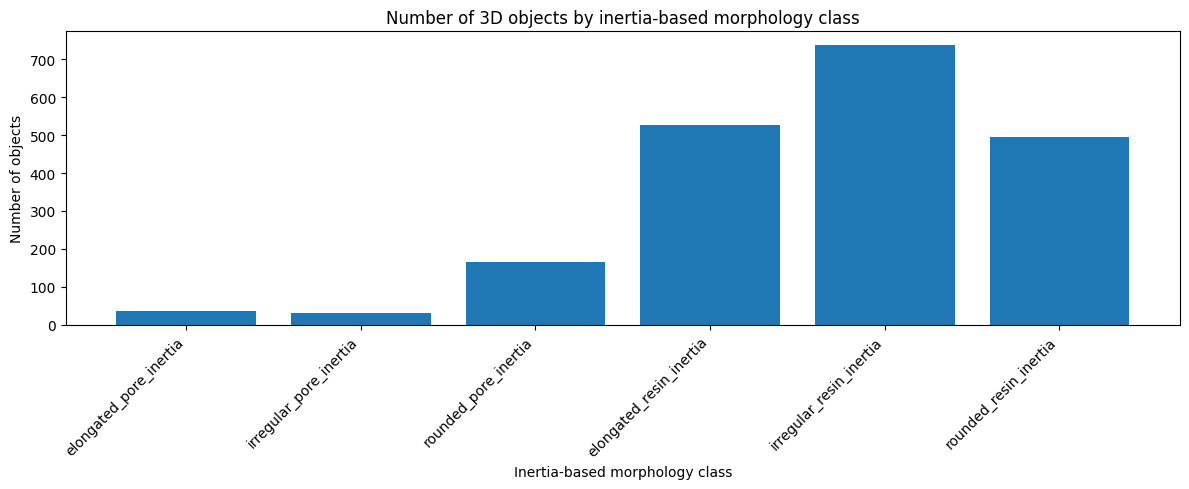

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\morphology_3d_inertia_class_counts.png


In [83]:
# ============================================================
# Cell 83 - Plot and save inertia-based 3D morphology class counts
# ============================================================

out_path = FIGURES_DIR / "morphology_3d_inertia_class_counts.png"

class_counts_3d_inertia = (
    df_components_3d
    .groupby(["phase", "morphology_class_3d_inertia"])
    .size()
    .reset_index(name="number_of_objects")
)

fig, ax = plt.subplots(figsize=(12, 5))

x_labels = class_counts_3d_inertia["morphology_class_3d_inertia"]
x_positions = np.arange(len(class_counts_3d_inertia))

ax.bar(x_positions, class_counts_3d_inertia["number_of_objects"])

ax.set_title("Number of 3D objects by inertia-based morphology class")
ax.set_xlabel("Inertia-based morphology class")
ax.set_ylabel("Number of objects")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [84]:
# ============================================================
# Cell 84 - Summary of inertia-based 3D morphology classes
# ============================================================

df_morphology_3d_inertia_summary = (
    df_components_3d
    .groupby(["phase", "morphology_class_3d_inertia"])
    .agg(
        number_of_objects=("label_3d", "count"),
        mean_volume_voxels=("volume_voxels", "mean"),
        median_volume_voxels=("volume_voxels", "median"),
        mean_volume_mm3=("volume_mm3", "mean"),
        median_volume_mm3=("volume_mm3", "median"),
        mean_equivalent_diameter_um=("equivalent_diameter_um", "mean"),
        median_equivalent_diameter_um=("equivalent_diameter_um", "median"),
        mean_axis_ratio_3d=("axis_ratio_3d", "mean"),
        median_axis_ratio_3d=("axis_ratio_3d", "median"),
        mean_extent_3d=("extent_3d", "mean"),
        median_extent_3d=("extent_3d", "median"),
        mean_intensity=("mean_intensity", "mean"),
        median_intensity=("mean_intensity", "median")
    )
    .reset_index()
)

df_morphology_3d_inertia_summary

,phase,morphology_class_3d_inertia,number_of_objects,mean_volume_voxels,median_volume_voxels,mean_volume_mm3,median_volume_mm3,mean_equivalent_diameter_um,median_equivalent_diameter_um,mean_axis_ratio_3d,median_axis_ratio_3d,mean_extent_3d,median_extent_3d,mean_intensity,median_intensity
0,pores,elongated_pore_inertia,36,139.055556,113.5,0.071196,0.058112,501.904934,480.559652,2.578631,2.616070,0.172859,0.158961,72.777436,75.690963
1,pores,irregular_pore_inertia,31,286.451613,114.0,0.146663,0.058368,528.487120,481.273627,1.617268,1.607833,0.296178,0.265276,74.002358,80.032680
2,pores,rounded_pore_inertia,165,669.818182,128.0,0.342947,0.065536,592.684621,500.219291,1.120851,1.096848,0.519368,0.517007,57.285108,57.504854
3,resin,elongated_resin_inertia,526,5462.714829,572.0,2.796910,0.292864,897.324957,823.927456,3.027195,2.878655,0.195651,0.174913,131.479462,130.427039
4,resin,irregular_resin_inertia,737,265.645862,181.0,0.136011,0.092672,600.616618,561.457177,1.951118,1.910606,0.326692,0.314286,133.843814,132.631068
5,resin,rounded_resin_inertia,494,225.868421,200.0,0.115645,0.102400,588.685637,580.453069,1.193198,1.119799,0.457844,0.454433,130.278312,127.336614


In [85]:
# ============================================================
# Cell 85 - Compare bounding-box and inertia-based 3D classifications
# ============================================================

df_classification_comparison = (
    df_components_3d
    .groupby(["phase", "morphology_class_3d", "morphology_class_3d_inertia"])
    .size()
    .reset_index(name="number_of_objects")
    .sort_values(["phase", "number_of_objects"], ascending=[True, False])
)

df_classification_comparison

,phase,morphology_class_3d,morphology_class_3d_inertia,number_of_objects
0,pores,compact_pore,rounded_pore_inertia,163
1,pores,elongated_pore,elongated_pore_inertia,32
4,pores,irregular_pore,irregular_pore_inertia,25
2,pores,elongated_pore,irregular_pore_inertia,6
3,pores,irregular_pore,elongated_pore_inertia,4
5,pores,irregular_pore,rounded_pore_inertia,2
12,resin,irregular_resin,irregular_resin_inertia,479
8,resin,compact_resin,rounded_resin_inertia,434
9,resin,elongated_resin,elongated_resin_inertia,431
7,resin,compact_resin,irregular_resin_inertia,155


In [86]:
# ============================================================
# Cell 86 - Save inertia-based 3D morphology classification tables
# ============================================================

out_components_csv = RESULTS_DIR / "components_3d_with_bbox_and_inertia_morphology.csv"
out_summary_csv = RESULTS_DIR / "morphology_3d_inertia_summary.csv"
out_comparison_csv = RESULTS_DIR / "morphology_3d_bbox_vs_inertia_comparison.csv"

df_components_3d.to_csv(out_components_csv, index=False)
df_morphology_3d_inertia_summary.to_csv(out_summary_csv, index=False)
df_classification_comparison.to_csv(out_comparison_csv, index=False)

print(f"3D components with bbox and inertia morphology saved to: {out_components_csv}")
print(f"Inertia-based morphology summary saved to: {out_summary_csv}")
print(f"BBox vs inertia classification comparison saved to: {out_comparison_csv}")

3D components with bbox and inertia morphology saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\components_3d_with_bbox_and_inertia_morphology.csv
Inertia-based morphology summary saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\morphology_3d_inertia_summary.csv
BBox vs inertia classification comparison saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\morphology_3d_bbox_vs_inertia_comparison.csv


In [87]:
# ============================================================
# Cell 87 - Compare number of objects detected in 2D and 3D
# ============================================================

# Number of 2D objects by phase
df_2d_object_counts = (
    df_components_2d
    .groupby("phase")
    .size()
    .reset_index(name="objects_2d")
)

# Number of 3D objects by phase
df_3d_object_counts = (
    df_components_3d
    .groupby("phase")
    .size()
    .reset_index(name="objects_3d")
)

# Merge comparison
df_object_count_comparison = pd.merge(
    df_2d_object_counts,
    df_3d_object_counts,
    on="phase",
    how="outer"
)

df_object_count_comparison["objects_2d_per_3d_object"] = (
    df_object_count_comparison["objects_2d"] /
    df_object_count_comparison["objects_3d"]
)

df_object_count_comparison

,phase,objects_2d,objects_3d,objects_2d_per_3d_object
0,pores,5280,232,22.758621
1,resin,86333,1757,49.136596


In [88]:
# ============================================================
# Cell 89 - Compare equivalent diameter statistics in 2D and 3D
# ============================================================

df_diameter_2d_stats = (
    df_components_2d
    .groupby("phase")
    .agg(
        mean_equivalent_diameter_2d_um=("equivalent_diameter_um", "mean"),
        median_equivalent_diameter_2d_um=("equivalent_diameter_um", "median"),
        std_equivalent_diameter_2d_um=("equivalent_diameter_um", "std")
    )
    .reset_index()
)

df_diameter_3d_stats = (
    df_components_3d
    .groupby("phase")
    .agg(
        mean_equivalent_diameter_3d_um=("equivalent_diameter_um", "mean"),
        median_equivalent_diameter_3d_um=("equivalent_diameter_um", "median"),
        std_equivalent_diameter_3d_um=("equivalent_diameter_um", "std")
    )
    .reset_index()
)

df_diameter_comparison = pd.merge(
    df_diameter_2d_stats,
    df_diameter_3d_stats,
    on="phase",
    how="outer"
)

df_diameter_comparison

,phase,mean_equivalent_diameter_2d_um,median_equivalent_diameter_2d_um,std_equivalent_diameter_2d_um,mean_equivalent_diameter_3d_um,median_equivalent_diameter_3d_um,std_equivalent_diameter_3d_um
0,pores,362.344433,270.811000,331.069805,570.020004,496.280393,305.929826
1,resin,499.255427,469.058411,225.235480,686.088833,613.377414,389.979221


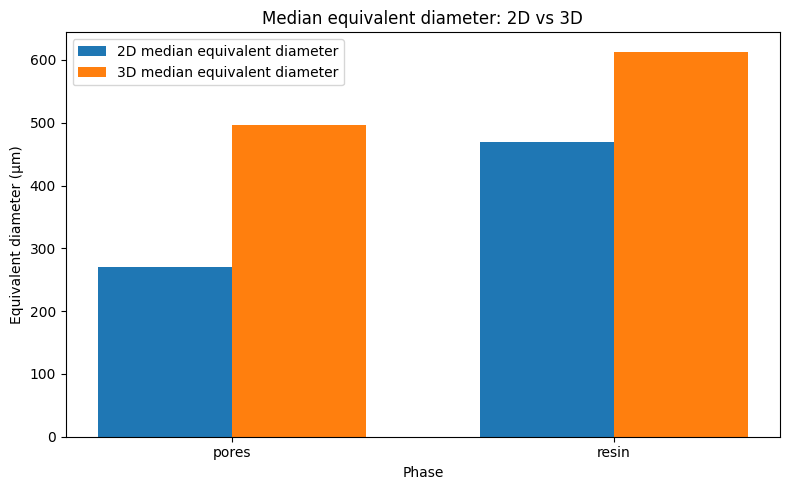

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\equivalent_diameter_2d_vs_3d_comparison.png


In [89]:
# ============================================================
# Cell 90 - Plot and save 2D vs 3D equivalent diameter comparison
# ============================================================

out_path = FIGURES_DIR / "equivalent_diameter_2d_vs_3d_comparison.png"

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(df_diameter_comparison))
width = 0.35

ax.bar(
    x - width / 2,
    df_diameter_comparison["median_equivalent_diameter_2d_um"],
    width,
    label="2D median equivalent diameter"
)

ax.bar(
    x + width / 2,
    df_diameter_comparison["median_equivalent_diameter_3d_um"],
    width,
    label="3D median equivalent diameter"
)

ax.set_title("Median equivalent diameter: 2D vs 3D")
ax.set_xlabel("Phase")
ax.set_ylabel("Equivalent diameter (µm)")
ax.set_xticks(x)
ax.set_xticklabels(df_diameter_comparison["phase"])
ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [90]:
# ============================================================
# Cell 91 - Compare mean intensity statistics in 2D and 3D
# ============================================================

df_intensity_2d_stats = (
    df_components_2d
    .groupby("phase")
    .agg(
        mean_intensity_2d=("mean_intensity", "mean"),
        median_intensity_2d=("mean_intensity", "median"),
        std_intensity_2d=("mean_intensity", "std")
    )
    .reset_index()
)

df_intensity_3d_stats = (
    df_components_3d
    .groupby("phase")
    .agg(
        mean_intensity_3d=("mean_intensity", "mean"),
        median_intensity_3d=("mean_intensity", "median"),
        std_intensity_3d=("mean_intensity", "std")
    )
    .reset_index()
)

df_intensity_comparison = pd.merge(
    df_intensity_2d_stats,
    df_intensity_3d_stats,
    on="phase",
    how="outer"
)

df_intensity_comparison

,phase,mean_intensity_2d,median_intensity_2d,std_intensity_2d,mean_intensity_3d,median_intensity_3d,std_intensity_3d
0,pores,64.928671,63.375000,9.761493,61.922860,58.269509,10.085345
1,resin,133.814264,132.846154,11.491756,132.133508,130.658038,7.504055


In [91]:
# ============================================================
# Cell 92 - Save 2D vs 3D comparison tables
# ============================================================

out_counts_csv = RESULTS_DIR / "comparison_object_counts_2d_vs_3d.csv"
out_diameters_csv = RESULTS_DIR / "comparison_equivalent_diameter_2d_vs_3d.csv"
out_intensity_csv = RESULTS_DIR / "comparison_intensity_2d_vs_3d.csv"

df_object_count_comparison.to_csv(out_counts_csv, index=False)
df_diameter_comparison.to_csv(out_diameters_csv, index=False)
df_intensity_comparison.to_csv(out_intensity_csv, index=False)

print(f"Object count comparison saved to: {out_counts_csv}")
print(f"Equivalent diameter comparison saved to: {out_diameters_csv}")
print(f"Intensity comparison saved to: {out_intensity_csv}")

Object count comparison saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\comparison_object_counts_2d_vs_3d.csv
Equivalent diameter comparison saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\comparison_equivalent_diameter_2d_vs_3d.csv
Intensity comparison saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\comparison_intensity_2d_vs_3d.csv


In [102]:
# ============================================================
# Cell 93 - Diagnostic: resin component size distribution
# ============================================================

# Label raw 3D resin connected components
resin_labeled_raw = measure.label(resin_mask, connectivity=3)

# Component sizes in voxels
resin_sizes = np.bincount(resin_labeled_raw.ravel())
resin_sizes = resin_sizes[1:]  # remove background

df_resin_raw_sizes = pd.DataFrame({
    "volume_voxels": resin_sizes
})

# Test different minimum-size thresholds
size_thresholds = [1, 5, 10, 20, 50, 100, 120, 200, 500, 1000]

rows = []

for thr in size_thresholds:
    components_kept = df_resin_raw_sizes["volume_voxels"] >= thr
    
    n_components = components_kept.sum()
    total_voxels_kept = df_resin_raw_sizes.loc[
        components_kept,
        "volume_voxels"
    ].sum()
    
    rows.append({
        "min_volume_voxels": thr,
        "number_of_components": n_components,
        "total_resin_voxels_kept": total_voxels_kept,
        "fraction_of_resin_voxels_kept": total_voxels_kept / resin_mask.sum()
    })

df_resin_component_size_diagnostic = pd.DataFrame(rows)

df_resin_component_size_diagnostic

,min_volume_voxels,number_of_components,total_resin_voxels_kept,fraction_of_resin_voxels_kept
0,1,14856,3265945,1.000000
1,5,5464,3251353,0.995532
2,10,3939,3241325,0.992462
3,20,2894,3226974,0.988067
4,50,2097,3202401,0.980543
5,100,1586,3165418,0.969220
6,120,1417,3146877,0.963543
7,200,1011,3083167,0.944035
8,500,395,2892236,0.885574
9,1000,164,2731611,0.836392


In [103]:
# ============================================================
# Cell 94 - Create refined resin mask for object-level analysis
# ============================================================

MIN_RESIN_COMPONENT_VOXELS = 50

# Label raw 3D resin connected components
resin_labeled_raw = measure.label(resin_mask, connectivity=3)

# Compute component sizes
resin_sizes = np.bincount(resin_labeled_raw.ravel())

# Keep only resin components with at least 50 connected voxels
valid_resin_labels = np.where(resin_sizes >= MIN_RESIN_COMPONENT_VOXELS)[0]
valid_resin_labels = valid_resin_labels[valid_resin_labels != 0]  # remove background

resin_mask_refined = np.isin(resin_labeled_raw, valid_resin_labels)

print("Refined resin mask created.")
print("Original resin components:", resin_labeled_raw.max())
print("Refined resin components:", len(valid_resin_labels))
print("Original resin voxels:", resin_mask.sum())
print("Refined resin voxels:", resin_mask_refined.sum())
print("Fraction of resin voxels kept:", resin_mask_refined.sum() / resin_mask.sum())

Refined resin mask created.
Original resin components: 14856
Refined resin components: 2097
Original resin voxels: 3265945
Refined resin voxels: 3202401
Fraction of resin voxels kept: 0.9805434567942816


In [105]:
# ============================================================
# Cell 95 - Recompute 3D resin components using refined resin mask
# ============================================================

rows_resin_3d_refined = analyze_3d_components(
    mask_3d=resin_mask_refined,
    intensity_volume=volume,
    phase_name="resin_refined",
    min_volume_voxels=MIN_RESIN_COMPONENT_VOXELS
)

df_resin_3d_refined = pd.DataFrame(rows_resin_3d_refined)

print("Refined 3D resin component analysis completed.")
print("Number of refined resin objects:", len(df_resin_3d_refined))

df_resin_3d_refined.head()

Refined 3D resin component analysis completed.
Number of refined resin objects: 2097


,phase,label_3d,volume_voxels,volume_mm3,equivalent_diameter_voxels,equivalent_diameter_um,centroid_z_pixels,centroid_y_pixels,centroid_x_pixels,centroid_z_mm,...,bbox_x_mm,longest_axis_bbox_pixels,intermediate_axis_bbox_pixels,shortest_axis_bbox_pixels,elongation_bbox,flatness_bbox,extent_3d,mean_intensity,min_intensity,max_intensity
0,resin_refined,1,2295340.0,1175.214080,163.662608,13093.008643,204.788919,85.724613,101.926275,16.383114,...,16.16,435.0,202.0,178.0,2.443820,2.153465,0.146753,128.847738,88.0,168.0
1,resin_refined,2,108.0,0.055296,5.908470,472.677610,0.629630,8.481481,97.611111,0.050370,...,0.80,17.0,10.0,5.0,3.400000,1.700000,0.127059,142.240741,90.0,168.0
2,resin_refined,3,197.0,0.100864,7.219202,577.536170,5.934010,99.888325,107.126904,0.474721,...,1.04,13.0,11.0,11.0,1.181818,1.181818,0.125238,140.690355,107.0,168.0
3,resin_refined,4,72.0,0.036864,5.161524,412.921927,1.333333,101.027778,67.388889,0.106667,...,0.56,7.0,7.0,5.0,1.400000,1.000000,0.293878,137.305556,88.0,168.0
4,resin_refined,5,492.0,0.251904,9.794648,783.571829,4.802846,115.983740,61.796748,0.384228,...,1.76,22.0,14.0,13.0,1.692308,1.571429,0.122877,143.174797,95.0,168.0


In [106]:
# ============================================================
# Cell 96 - Compare original and refined 3D resin measurements
# ============================================================

df_resin_original_3d = df_components_3d[df_components_3d["phase"] == "resin"].copy()

comparison_rows = []

for name, df_tmp in [
    ("resin_original_ge20", df_resin_original_3d),
    ("resin_refined_ge50", df_resin_3d_refined)
]:
    comparison_rows.append({
        "dataset": name,
        "number_of_objects": len(df_tmp),
        "total_volume_voxels": df_tmp["volume_voxels"].sum(),
        "total_volume_mm3": df_tmp["volume_mm3"].sum(),
        "median_volume_voxels": df_tmp["volume_voxels"].median(),
        "mean_volume_voxels": df_tmp["volume_voxels"].mean(),
        "median_equivalent_diameter_um": df_tmp["equivalent_diameter_um"].median(),
        "mean_equivalent_diameter_um": df_tmp["equivalent_diameter_um"].mean(),
        "median_elongation_bbox": df_tmp["elongation_bbox"].median(),
        "mean_elongation_bbox": df_tmp["elongation_bbox"].mean(),
        "median_extent_3d": df_tmp["extent_3d"].median(),
        "mean_extent_3d": df_tmp["extent_3d"].mean(),
        "median_intensity": df_tmp["mean_intensity"].median(),
        "mean_intensity": df_tmp["mean_intensity"].mean(),
    })

df_resin_refinement_comparison = pd.DataFrame(comparison_rows)

df_resin_refinement_comparison

,dataset,number_of_objects,total_volume_voxels,total_volume_mm3,median_volume_voxels,mean_volume_voxels,median_equivalent_diameter_um,mean_equivalent_diameter_um,median_elongation_bbox,mean_elongation_bbox,median_extent_3d,mean_extent_3d,median_intensity,mean_intensity
0,resin_original_ge20,1757,3180748.0,1628.542976,236.0,1810.328970,613.377414,686.088833,1.363636,1.499497,0.322751,0.324337,130.658038,132.133508
1,resin_refined_ge50,2097,3202401.0,1639.629312,191.0,1527.134478,571.612304,638.982303,1.375000,1.521127,0.331731,0.331098,132.376471,133.492637


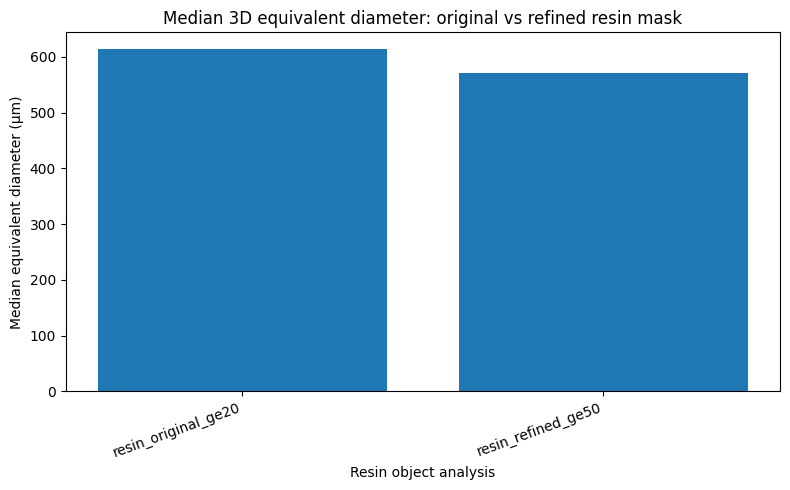

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\resin_original_vs_refined_diameter_comparison.png


In [107]:
# ============================================================
# Cell 97 - Plot and save original vs refined resin diameter comparison
# ============================================================

out_path = FIGURES_DIR / "resin_original_vs_refined_diameter_comparison.png"

fig, ax = plt.subplots(figsize=(8, 5))

labels = df_resin_refinement_comparison["dataset"]
values = df_resin_refinement_comparison["median_equivalent_diameter_um"]

x = np.arange(len(labels))

ax.bar(x, values)

ax.set_title("Median 3D equivalent diameter: original vs refined resin mask")
ax.set_xlabel("Resin object analysis")
ax.set_ylabel("Median equivalent diameter (µm)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [108]:
# ============================================================
# Cell 99 - Size-constrained 3D separation of large resin components
# ============================================================

from skimage.feature import peak_local_max

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

# Minimum size already used for object-level resin analysis
MIN_RESIN_COMPONENT_VOXELS = 50

# Approximate expected resin diameter
EXPECTED_RESIN_DIAMETER_UM = 500
EXPECTED_RESIN_DIAMETER_VOXELS = EXPECTED_RESIN_DIAMETER_UM / VOXEL_SIZE_UM

# Approximate expected spherical resin volume in voxels
EXPECTED_RESIN_VOLUME_VOXELS = (np.pi / 6) * EXPECTED_RESIN_DIAMETER_VOXELS**3

# Only components clearly larger than a single expected resin are split
SPLIT_VOLUME_THRESHOLD = 3 * EXPECTED_RESIN_VOLUME_VOXELS

# Conservative watershed parameters
PEAK_MIN_DISTANCE = 4
PEAK_THRESHOLD_ABS = 2.0

print("Expected resin diameter in voxels:", EXPECTED_RESIN_DIAMETER_VOXELS)
print("Expected resin volume in voxels:", EXPECTED_RESIN_VOLUME_VOXELS)
print("Split volume threshold in voxels:", SPLIT_VOLUME_THRESHOLD)

# ------------------------------------------------------------
# Label refined resin mask
# ------------------------------------------------------------

resin_refined_labeled = measure.label(resin_mask_refined, connectivity=3)
resin_refined_props = measure.regionprops(resin_refined_labeled)

# Output separated label volume
resin_separated_labels = np.zeros_like(resin_refined_labeled, dtype=np.int32)

current_label = 1
n_kept_without_split = 0
n_large_components_processed = 0
n_watershed_objects_generated = 0

# ------------------------------------------------------------
# Process each refined component
# ------------------------------------------------------------

for prop in resin_refined_props:
    
    if prop.area < MIN_RESIN_COMPONENT_VOXELS:
        continue
    
    min_z, min_y, min_x, max_z, max_y, max_x = prop.bbox
    
    component_crop = (
        resin_refined_labeled[min_z:max_z, min_y:max_y, min_x:max_x] == prop.label
    )
    
    # Keep normal-sized components as single objects
    if prop.area < SPLIT_VOLUME_THRESHOLD:
        resin_separated_labels[min_z:max_z, min_y:max_y, min_x:max_x][component_crop] = current_label
        current_label += 1
        n_kept_without_split += 1
        continue
    
    # Try watershed only for large components
    distance_crop = ndi.distance_transform_edt(component_crop)
    
    peak_coords = peak_local_max(
        distance_crop,
        min_distance=PEAK_MIN_DISTANCE,
        threshold_abs=PEAK_THRESHOLD_ABS,
        labels=component_crop,
        exclude_border=False
    )
    
    # If there are not enough reliable seeds, keep as a single object
    if len(peak_coords) <= 1:
        resin_separated_labels[min_z:max_z, min_y:max_y, min_x:max_x][component_crop] = current_label
        current_label += 1
        n_kept_without_split += 1
        continue
    
    markers_crop = np.zeros_like(component_crop, dtype=np.int32)
    
    for marker_id, coord in enumerate(peak_coords, start=1):
        z, y, x = coord
        markers_crop[z, y, x] = marker_id
    
    markers_crop = measure.label(markers_crop > 0, connectivity=3)
    
    watershed_crop = segmentation.watershed(
        -distance_crop,
        markers=markers_crop,
        mask=component_crop
    )
    
    for local_label in range(1, watershed_crop.max() + 1):
        local_object = watershed_crop == local_label
        
        resin_separated_labels[min_z:max_z, min_y:max_y, min_x:max_x][local_object] = current_label
        current_label += 1
        n_watershed_objects_generated += 1
    
    n_large_components_processed += 1

n_final_separated_resin_objects = current_label - 1

print("\nSize-constrained resin separation completed.")
print("Refined resin components before separation:", resin_refined_labeled.max())
print("Components kept without split:", n_kept_without_split)
print("Large components processed with watershed:", n_large_components_processed)
print("Watershed-generated objects from large components:", n_watershed_objects_generated)
print("Final separated resin objects:", n_final_separated_resin_objects)

Expected resin diameter in voxels: 6.25
Expected resin volume in voxels: 127.83173232380342
Split volume threshold in voxels: 383.4951969714103

Size-constrained resin separation completed.
Refined resin components before separation: 2097
Components kept without split: 1673
Large components processed with watershed: 424
Watershed-generated objects from large components: 9258
Final separated resin objects: 10931


In [109]:
# ============================================================
# Cell 100 - Measure size-constrained separated resin objects
# ============================================================

def analyze_labeled_3d_objects(labeled_volume, intensity_volume, phase_name, min_volume_voxels=50):
    """
    Analyze already-labeled 3D objects.
    """

    props = measure.regionprops(
        labeled_volume,
        intensity_image=intensity_volume
    )
    
    rows = []
    
    for prop in props:
        if prop.area < min_volume_voxels:
            continue
        
        volume_voxels = prop.area
        volume_mm3 = volume_voxels * voxel_volume_mm3
        
        equivalent_diameter_voxels = (6.0 * volume_voxels / np.pi) ** (1.0 / 3.0)
        equivalent_diameter_um = equivalent_diameter_voxels * VOXEL_SIZE_UM
        
        centroid_z, centroid_y, centroid_x = prop.centroid
        
        min_z, min_y, min_x, max_z, max_y, max_x = prop.bbox
        
        bbox_z = max_z - min_z
        bbox_y = max_y - min_y
        bbox_x = max_x - min_x
        
        bbox_lengths = np.array([bbox_z, bbox_y, bbox_x], dtype=float)
        bbox_sorted = np.sort(bbox_lengths)
        
        shortest_axis = bbox_sorted[0]
        intermediate_axis = bbox_sorted[1]
        longest_axis = bbox_sorted[2]
        
        elongation_bbox = longest_axis / shortest_axis if shortest_axis > 0 else np.nan
        flatness_bbox = longest_axis / intermediate_axis if intermediate_axis > 0 else np.nan
        
        bbox_volume_voxels = bbox_z * bbox_y * bbox_x
        extent_3d = volume_voxels / bbox_volume_voxels if bbox_volume_voxels > 0 else np.nan
        
        rows.append({
            "phase": phase_name,
            "label_3d": prop.label,
            "volume_voxels": volume_voxels,
            "volume_mm3": volume_mm3,
            "equivalent_diameter_voxels": equivalent_diameter_voxels,
            "equivalent_diameter_um": equivalent_diameter_um,
            "centroid_z_pixels": centroid_z,
            "centroid_y_pixels": centroid_y,
            "centroid_x_pixels": centroid_x,
            "centroid_z_mm": centroid_z * voxel_size_mm,
            "centroid_y_mm": centroid_y * voxel_size_mm,
            "centroid_x_mm": centroid_x * voxel_size_mm,
            "bbox_z_pixels": bbox_z,
            "bbox_y_pixels": bbox_y,
            "bbox_x_pixels": bbox_x,
            "elongation_bbox": elongation_bbox,
            "flatness_bbox": flatness_bbox,
            "extent_3d": extent_3d,
            "mean_intensity": prop.intensity_mean,
            "min_intensity": prop.intensity_min,
            "max_intensity": prop.intensity_max,
        })
    
    return rows


rows_resin_3d_separated = analyze_labeled_3d_objects(
    labeled_volume=resin_separated_labels,
    intensity_volume=volume,
    phase_name="resin_separated",
    min_volume_voxels=MIN_RESIN_COMPONENT_VOXELS
)

df_resin_3d_separated = pd.DataFrame(rows_resin_3d_separated)

print("Separated resin object measurement completed.")
print("Number of separated resin objects:", len(df_resin_3d_separated))

df_resin_3d_separated.head()

Separated resin object measurement completed.
Number of separated resin objects: 10925


,phase,label_3d,volume_voxels,volume_mm3,equivalent_diameter_voxels,equivalent_diameter_um,centroid_z_pixels,centroid_y_pixels,centroid_x_pixels,centroid_z_mm,...,centroid_x_mm,bbox_z_pixels,bbox_y_pixels,bbox_x_pixels,elongation_bbox,flatness_bbox,extent_3d,mean_intensity,min_intensity,max_intensity
0,resin_separated,1,439.0,0.224768,9.429499,754.359944,2.325740,7.264237,4.799544,0.186059,...,0.383964,9,15,13,1.666667,1.153846,0.250142,129.473804,88.0,168.0
1,resin_separated,2,935.0,0.478720,12.132147,970.571758,4.575401,7.901604,82.396791,0.366032,...,6.591743,12,21,19,1.750000,1.105263,0.195280,128.760428,88.0,168.0
2,resin_separated,3,681.0,0.348672,10.915647,873.251788,2.425844,7.656388,181.577093,0.194068,...,14.526167,10,18,26,2.600000,1.444444,0.145513,128.079295,88.0,168.0
3,resin_separated,4,404.0,0.206848,9.171934,733.754709,2.650990,19.448020,59.992574,0.212079,...,4.799406,11,18,22,2.000000,1.222222,0.092746,137.977723,88.0,168.0
4,resin_separated,5,888.0,0.454656,11.925359,954.028689,5.549550,25.844595,49.296171,0.443964,...,3.943694,15,17,25,1.666667,1.470588,0.139294,133.274775,88.0,168.0


In [111]:
# ============================================================
# Cell 101 - Compare original, refined and separated resin measurements
# ============================================================

df_resin_original_3d = df_components_3d[df_components_3d["phase"] == "resin"].copy()

comparison_rows = []

for name, df_tmp in [
    ("resin_original_ge20", df_resin_original_3d),
    ("resin_refined_ge50", df_resin_3d_refined),
    ("resin_separated_ge50", df_resin_3d_separated)
]:
    comparison_rows.append({
        "dataset": name,
        "number_of_objects": len(df_tmp),
        "total_volume_voxels": df_tmp["volume_voxels"].sum(),
        "total_volume_mm3": df_tmp["volume_mm3"].sum(),
        "median_volume_voxels": df_tmp["volume_voxels"].median(),
        "mean_volume_voxels": df_tmp["volume_voxels"].mean(),
        "median_equivalent_diameter_um": df_tmp["equivalent_diameter_um"].median(),
        "mean_equivalent_diameter_um": df_tmp["equivalent_diameter_um"].mean(),
        "median_elongation_bbox": df_tmp["elongation_bbox"].median(),
        "mean_elongation_bbox": df_tmp["elongation_bbox"].mean(),
        "median_extent_3d": df_tmp["extent_3d"].median(),
        "mean_extent_3d": df_tmp["extent_3d"].mean(),
        "median_intensity": df_tmp["mean_intensity"].median(),
        "mean_intensity": df_tmp["mean_intensity"].mean(),
    })

df_resin_object_analysis_comparison = pd.DataFrame(comparison_rows)

df_resin_object_analysis_comparison

,dataset,number_of_objects,total_volume_voxels,total_volume_mm3,median_volume_voxels,mean_volume_voxels,median_equivalent_diameter_um,mean_equivalent_diameter_um,median_elongation_bbox,mean_elongation_bbox,median_extent_3d,mean_extent_3d,median_intensity,mean_intensity
0,resin_original_ge20,1757,3180748.0,1628.542976,236.0,1810.328970,613.377414,686.088833,1.363636,1.499497,0.322751,0.324337,130.658038,132.133508
1,resin_refined_ge50,2097,3202401.0,1639.629312,191.0,1527.134478,571.612304,638.982303,1.375000,1.521127,0.331731,0.331098,132.376471,133.492637
2,resin_separated_ge50,10925,3098157.0,1586.256384,252.0,283.584165,626.937084,630.061012,1.250000,1.365476,0.371493,0.368248,128.314050,130.309978


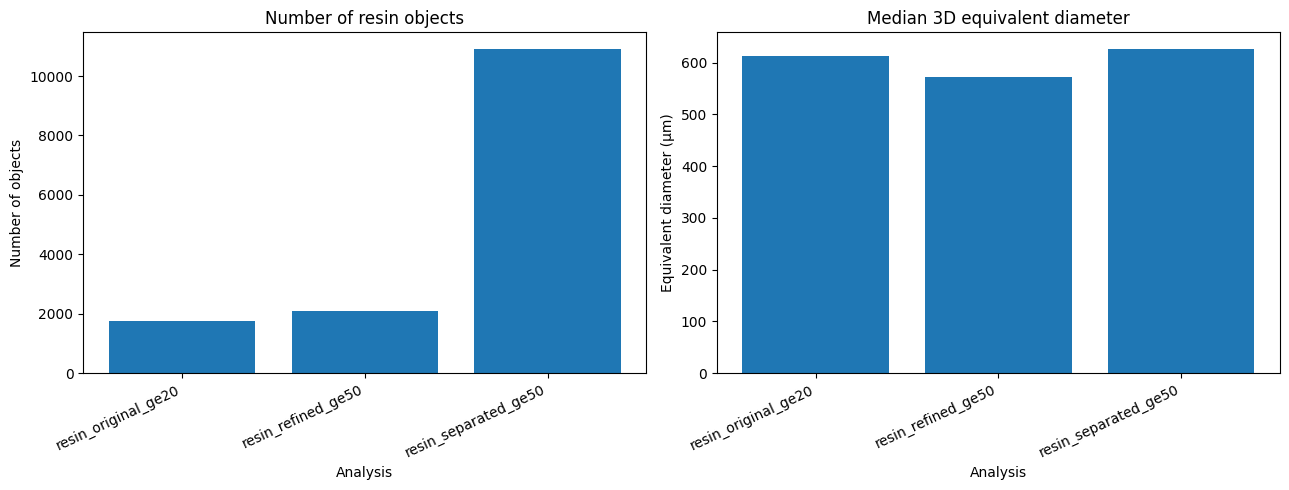

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\resin_original_refined_separated_comparison.png


In [112]:
# ============================================================
# Cell 102 - Plot and save resin object analysis comparison
# ============================================================

out_path = FIGURES_DIR / "resin_original_refined_separated_comparison.png"

labels = df_resin_object_analysis_comparison["dataset"]
x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    x,
    df_resin_object_analysis_comparison["number_of_objects"]
)
axes[0].set_title("Number of resin objects")
axes[0].set_xlabel("Analysis")
axes[0].set_ylabel("Number of objects")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=25, ha="right")

axes[1].bar(
    x,
    df_resin_object_analysis_comparison["median_equivalent_diameter_um"]
)
axes[1].set_title("Median 3D equivalent diameter")
axes[1].set_xlabel("Analysis")
axes[1].set_ylabel("Equivalent diameter (µm)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha="right")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [113]:
# ============================================================
# Cell 103 - Final decision for resin object-level analysis
# ============================================================

FINAL_RESIN_OBJECT_TABLE = df_resin_3d_refined.copy()
FINAL_RESIN_OBJECT_LABEL = "resin_refined_ge50"

print("Final resin object-level analysis selected:")
print(FINAL_RESIN_OBJECT_LABEL)
print()
print("Reason:")
print("- The refined resin mask removes small fragmented components.")
print("- It preserves ~98% of the resin-labeled volume.")
print("- It yields an interpretable number of resin-like objects.")
print("- Watershed separation was tested but not adopted due to oversegmentation.")
print()
print("Final number of resin-like objects:", len(FINAL_RESIN_OBJECT_TABLE))
print("Median equivalent diameter (µm):", FINAL_RESIN_OBJECT_TABLE["equivalent_diameter_um"].median())
print("Mean equivalent diameter (µm):", FINAL_RESIN_OBJECT_TABLE["equivalent_diameter_um"].mean())

Final resin object-level analysis selected:
resin_refined_ge50

Reason:
- The refined resin mask removes small fragmented components.
- It preserves ~98% of the resin-labeled volume.
- It yields an interpretable number of resin-like objects.
- Watershed separation was tested but not adopted due to oversegmentation.

Final number of resin-like objects: 2097
Median equivalent diameter (µm): 571.6123042568051
Mean equivalent diameter (µm): 638.9823032598251


In [114]:
"""
After removing resin-like connected components smaller than 50 voxels, the number of interpretable 3D resin objects was 
reduced to 2097 while preserving approximately 98% of the resin-labeled volume. The median 3D equivalent diameter of the refined 
resin components was 571.6 µm, which is consistent with the expected order of magnitude of the resin inclusions. The mean diameter 
remained higher, indicating the presence of larger or partially connected resin-like regions.
"""

'\nAfter removing resin-like connected components smaller than 50 voxels, the number of interpretable 3D resin objects was \nreduced to 2097 while preserving approximately 98% of the resin-labeled volume. The median 3D equivalent diameter of the refined \nresin components was 571.6 µm, which is consistent with the expected order of magnitude of the resin inclusions. The mean diameter \nremained higher, indicating the presence of larger or partially connected resin-like regions.\n'

In [115]:
# ============================================================
# Cell 104 - Final project summary table
# ============================================================

final_summary_rows = []

# Global phase fractions
final_summary_rows.append({
    "category": "phase_fraction",
    "metric": "pores_fraction_global",
    "value": pores_mask.mean(),
    "unit": "fraction"
})

final_summary_rows.append({
    "category": "phase_fraction",
    "metric": "resin_fraction_global",
    "value": resin_mask.mean(),
    "unit": "fraction"
})

final_summary_rows.append({
    "category": "phase_fraction",
    "metric": "material_fraction_global",
    "value": material_mask.mean(),
    "unit": "fraction"
})

# 2D object counts
for phase in df_components_2d["phase"].unique():
    df_phase = df_components_2d[df_components_2d["phase"] == phase]
    
    final_summary_rows.append({
        "category": "2d_components",
        "metric": f"{phase}_number_of_2d_objects",
        "value": len(df_phase),
        "unit": "objects"
    })
    
    final_summary_rows.append({
        "category": "2d_components",
        "metric": f"{phase}_median_equivalent_diameter_2d",
        "value": df_phase["equivalent_diameter_um"].median(),
        "unit": "um"
    })

# 3D pore object summary
df_pores_3d_final = df_components_3d[df_components_3d["phase"] == "pores"].copy()

final_summary_rows.append({
    "category": "3d_components",
    "metric": "pores_number_of_3d_objects",
    "value": len(df_pores_3d_final),
    "unit": "objects"
})

final_summary_rows.append({
    "category": "3d_components",
    "metric": "pores_median_equivalent_diameter_3d",
    "value": df_pores_3d_final["equivalent_diameter_um"].median(),
    "unit": "um"
})

# Final refined resin object summary
final_summary_rows.append({
    "category": "3d_components_refined",
    "metric": "resin_refined_number_of_3d_objects_ge50",
    "value": len(FINAL_RESIN_OBJECT_TABLE),
    "unit": "objects"
})

final_summary_rows.append({
    "category": "3d_components_refined",
    "metric": "resin_refined_median_equivalent_diameter_3d",
    "value": FINAL_RESIN_OBJECT_TABLE["equivalent_diameter_um"].median(),
    "unit": "um"
})

final_summary_rows.append({
    "category": "3d_components_refined",
    "metric": "resin_refined_mean_equivalent_diameter_3d",
    "value": FINAL_RESIN_OBJECT_TABLE["equivalent_diameter_um"].mean(),
    "unit": "um"
})

final_summary_rows.append({
    "category": "3d_components_refined",
    "metric": "resin_refined_volume_fraction_kept",
    "value": resin_mask_refined.sum() / resin_mask.sum(),
    "unit": "fraction"
})

df_final_project_summary = pd.DataFrame(final_summary_rows)

df_final_project_summary

,category,metric,value,unit
0,phase_fraction,pores_fraction_global,0.012330,fraction
1,phase_fraction,resin_fraction_global,0.208809,fraction
2,phase_fraction,material_fraction_global,0.778862,fraction
3,2d_components,pores_number_of_2d_objects,5280.000000,objects
4,2d_components,pores_median_equivalent_diameter_2d,270.811000,um
5,2d_components,resin_number_of_2d_objects,86333.000000,objects
6,2d_components,resin_median_equivalent_diameter_2d,469.058411,um
7,3d_components,pores_number_of_3d_objects,232.000000,objects
8,3d_components,pores_median_equivalent_diameter_3d,496.280393,um
9,3d_components_refined,resin_refined_number_of_3d_objects_ge50,2097.000000,objects


In [116]:
# ============================================================
# Cell 105 - Save final project summary
# ============================================================

out_csv = RESULTS_DIR / "final_project_summary.csv"

df_final_project_summary.to_csv(out_csv, index=False)

print(f"Final project summary saved to: {out_csv}")

Final project summary saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\final_project_summary.csv


In [117]:
# ============================================================
# Cell 106 - Save main processed masks and labels
# ============================================================

np.save(PROCESSED_DIR / "phase_labels_3class.npy", phase_labels)
np.save(PROCESSED_DIR / "pores_mask.npy", pores_mask)
np.save(PROCESSED_DIR / "resin_mask.npy", resin_mask)
np.save(PROCESSED_DIR / "material_mask.npy", material_mask)
np.save(PROCESSED_DIR / "resin_mask_refined_ge50.npy", resin_mask_refined)

print("Processed masks saved:")
print(PROCESSED_DIR / "phase_labels_3class.npy")
print(PROCESSED_DIR / "pores_mask.npy")
print(PROCESSED_DIR / "resin_mask.npy")
print(PROCESSED_DIR / "material_mask.npy")
print(PROCESSED_DIR / "resin_mask_refined_ge50.npy")

Processed masks saved:
C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\phase_labels_3class.npy
C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\pores_mask.npy
C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\resin_mask.npy
C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\material_mask.npy
C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\resin_mask_refined_ge50.npy


In [118]:
"""
## Final conclusions

This project analyzed a real 3D microCT subvolume extracted from a mortar sample. The volume was segmented into three intensity-based phases: pores, 
resin-like regions, and cementitious material.

The slice-by-slice phase fraction analysis showed that the selected subvolume is relatively homogeneous along the Z direction. Resin and material 
fractions remained stable with depth, while the pore fraction showed higher relative variability because pores occupy a much smaller volume fraction.

The comparison between 2D and 3D connected-component analysis showed that slice-by-slice measurements and volumetric measurements describe different 
aspects of the sample. In 2D, each object is measured as a cross-section. In 3D, connected regions are measured as volumetric structures. This explains 
why the number of objects and the equivalent diameters differ between 2D and 3D analysis.

For pores, the 3D connected-component analysis provides a physically meaningful estimate of pore size and spatial distribution. For resin-like regions, 
the raw intensity mask contained many small fragmented components. A minimum-size refinement was therefore applied for object-level analysis. 
By keeping only resin-like connected components with at least 50 voxels, the number of interpretable resin objects became 2097 while preserving 
approximately 98% of the resin-labeled volume.

A watershed-based separation of large resin regions was tested, but it was not adopted as the final method because it produced oversegmentation and 
did not improve the equivalent diameter estimate. Therefore, the final resin object-level analysis is based on the refined connected-component mask 
rather than watershed-separated objects.

Overall, this notebook demonstrates a complete quantitative 3D microCT workflow: volume loading, phase segmentation, slice-by-slice statistics, 
2D and 3D connected-component analysis, morphological classification, method validation, and final object-level refinement.
"""

'\n## Final conclusions\n\nThis project analyzed a real 3D microCT subvolume extracted from a mortar sample. The volume was segmented into three intensity-based phases: pores, \nresin-like regions, and cementitious material.\n\nThe slice-by-slice phase fraction analysis showed that the selected subvolume is relatively homogeneous along the Z direction. Resin and material \nfractions remained stable with depth, while the pore fraction showed higher relative variability because pores occupy a much smaller volume fraction.\n\nThe comparison between 2D and 3D connected-component analysis showed that slice-by-slice measurements and volumetric measurements describe different \naspects of the sample. In 2D, each object is measured as a cross-section. In 3D, connected regions are measured as volumetric structures. This explains \nwhy the number of objects and the equivalent diameters differ between 2D and 3D analysis.\n\nFor pores, the 3D connected-component analysis provides a physically mean

In [119]:
"""
## Methodological note on resin object analysis

The intensity range used for resin-like phase segmentation was retained for phase-fraction measurements. However, object-level measurements require additional filtering because very small connected components can arise from noise, partial-volume effects, local texture, or thin fragmented regions.

For this reason, the final resin object analysis uses connected components with at least 50 voxels. This threshold removes thousands of very small fragments while preserving about 98% of the resin-labeled volume. The resulting object count and median equivalent diameter are more physically interpretable.

The watershed separation test showed that automatic splitting of connected resin-like regions is not reliable at this voxel size without stronger prior information. The final interpretation therefore distinguishes between:

- resin-like phase fraction,
- refined resin-like connected components,
- and rejected watershed-separated objects.
"""

'\n## Methodological note on resin object analysis\n\nThe intensity range used for resin-like phase segmentation was retained for phase-fraction measurements. However, object-level measurements require additional filtering because very small connected components can arise from noise, partial-volume effects, local texture, or thin fragmented regions.\n\nFor this reason, the final resin object analysis uses connected components with at least 50 voxels. This threshold removes thousands of very small fragments while preserving about 98% of the resin-labeled volume. The resulting object count and median equivalent diameter are more physically interpretable.\n\nThe watershed separation test showed that automatic splitting of connected resin-like regions is not reliable at this voxel size without stronger prior information. The final interpretation therefore distinguishes between:\n\n- resin-like phase fraction,\n- refined resin-like connected components,\n- and rejected watershed-separated o